In [13]:
# 0. import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
%matplotlib inline
from matplotlib.ticker import MaxNLocator
import matplotlib.dates as mdates
import datetime
import json


=== Daily survey missingness summary (84-day active phase) ===
Participants: 29
Overall missingness rate: 58.8%

Participant-level missingness rate:
count    29.000000
mean      0.587849
std       0.310445
min       0.011905
25%       0.285714
50%       0.726190
75%       0.857143
max       1.000000

Number of missing daily surveys per participant (out of 84):
count    29.000000
mean     49.379310
std      26.077376
min       1.000000
25%      24.000000
50%      61.000000
75%      72.000000
max      84.000000

Participants with 0% missingness: 0
Participants with 100% missingness: 1

Day-averaged missingness across participants:
count    84.000000
mean      0.587849
std       0.087285
min       0.310345
25%       0.543103
50%       0.586207
75%       0.655172
max       0.758621


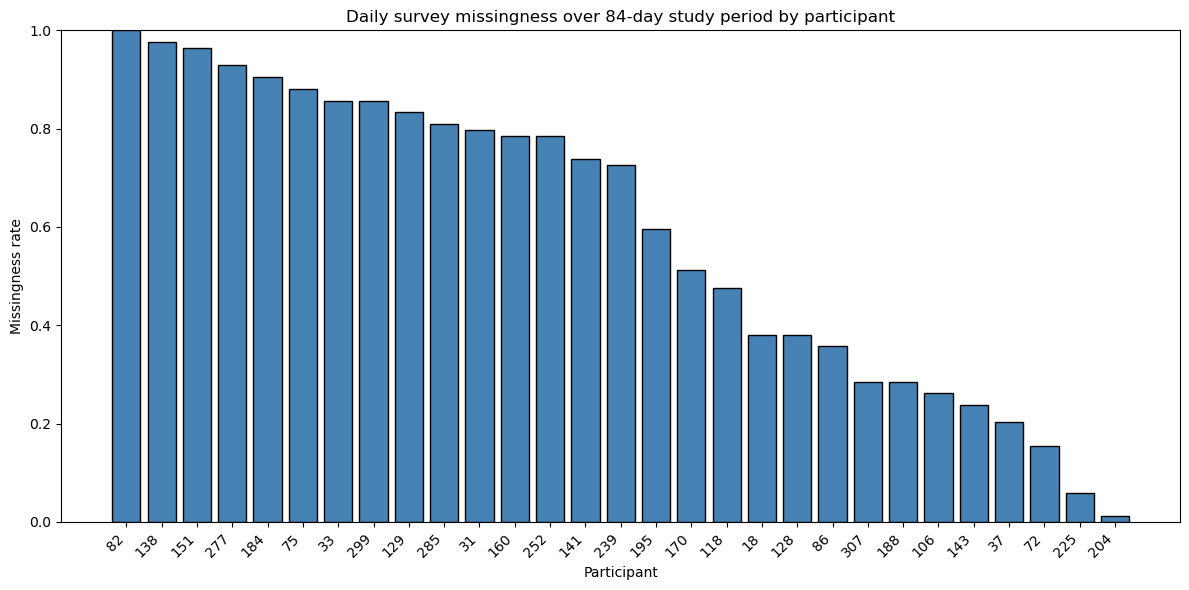

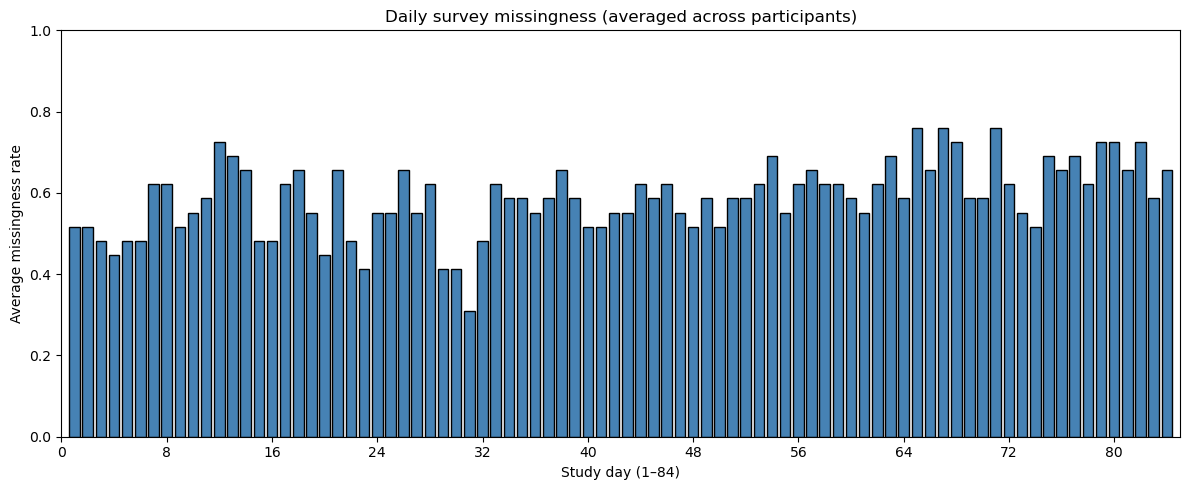

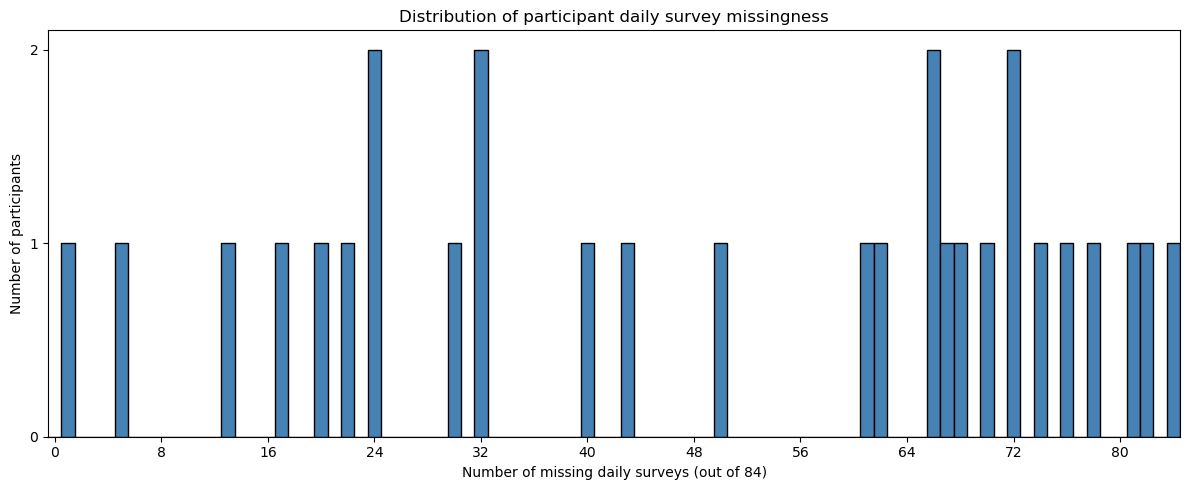

In [16]:
# 0.5 daily survey missingness (84-day active phase)
# requires the import cell above
folder = '/Users/xueqingliu/Harvard University Dropbox/Liu Xueqing/ADAPT_MRT/Xueqing'
df_daily_filled = pd.read_csv(os.path.join(folder, 'df_daily_filled.csv'))

id_col = 'ParticipantIdentifier' if 'ParticipantIdentifier' in df_daily_filled.columns else 'participantidentifier'

# keep the 84-day active window (days 1–84)
daily = (
    df_daily_filled.loc[df_daily_filled['day'].between(1, 84)]
    .sort_values([id_col, 'day'])
    .copy()
)
daily['missing_rate'] = 1 - daily['daily_present']

# --- plot 1: missingness rate per user over the whole study period ---
user_miss = (
    daily.groupby(id_col)['missing_rate']
    .mean()
    .sort_values(ascending=False)
)
participant_daily_missing = daily.groupby(id_col)['missing_rate'].sum()
daily_miss = daily.groupby('day', as_index=False)['missing_rate'].mean()

# --- summary statistics ---
print('=== Daily survey missingness summary (84-day active phase) ===')
print(f'Participants: {user_miss.shape[0]}')
print(f'Overall missingness rate: {daily["missing_rate"].mean():.1%}')
print()
print('Participant-level missingness rate:')
print(user_miss.describe().to_string())
print()
print('Number of missing daily surveys per participant (out of 84):')
print(participant_daily_missing.describe().to_string())
print()
print(f'Participants with 0% missingness: {(user_miss == 0).sum()}')
print(f'Participants with 100% missingness: {(user_miss == 1).sum()}')
print()
print('Day-averaged missingness across participants:')
print(daily_miss['missing_rate'].describe().to_string())

fig, ax = plt.subplots(figsize=(12, 6))
x_pos = range(len(user_miss))
ax.bar(x_pos, user_miss.values, color='steelblue', edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(user_miss.index.astype(str), rotation=45, ha='right')
ax.set_xlabel('Participant')
ax.set_ylabel('Missingness rate')
ax.set_title('Daily survey missingness over 84-day study period by participant')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

# --- plot 2: average daily missingness across participants ---

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(daily_miss['day'], daily_miss['missing_rate'], color='steelblue', edgecolor='black', width=0.8)
ax.set_xlabel('Study day (1–84)')
ax.set_ylabel('Average missingness rate')
ax.set_title('Daily survey missingness (averaged across participants)')
ax.set_xlim(0, 85)
ax.set_ylim(0, 1)
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=12))
plt.tight_layout()
plt.show()

# --- plot 3: distribution of the number of missing surveys per participant ---

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(
    participant_daily_missing,
    bins=np.arange(-0.5, 85.5, 1),
    color='steelblue',
    edgecolor='black',
)
ax.set_xlabel('Number of missing daily surveys (out of 84)')
ax.set_ylabel('Number of participants')
ax.set_title('Distribution of participant daily survey missingness')
ax.set_xlim(-0.5, 84.5)
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=12))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()


=== Weekly survey missingness summary (12-week active phase) ===
Participants: 29
Overall missingness rate: 35.6%

Participant-level missingness rate:
count    29.000000
mean      0.356322
std       0.336220
min       0.000000
25%       0.083333
50%       0.250000
75%       0.500000
max       0.916667

Number of missing weekly surveys per participant (out of 12):
count    29.000000
mean      4.275862
std       4.034641
min       0.000000
25%       1.000000
50%       3.000000
75%       6.000000
max      11.000000

Participants with 0% missingness: 7
Participants with 100% missingness: 0

Week-averaged missingness across participants:
count    12.000000
mean      0.356322
std       0.093380
min       0.206897
25%       0.301724
50%       0.362069
75%       0.387931
max       0.551724


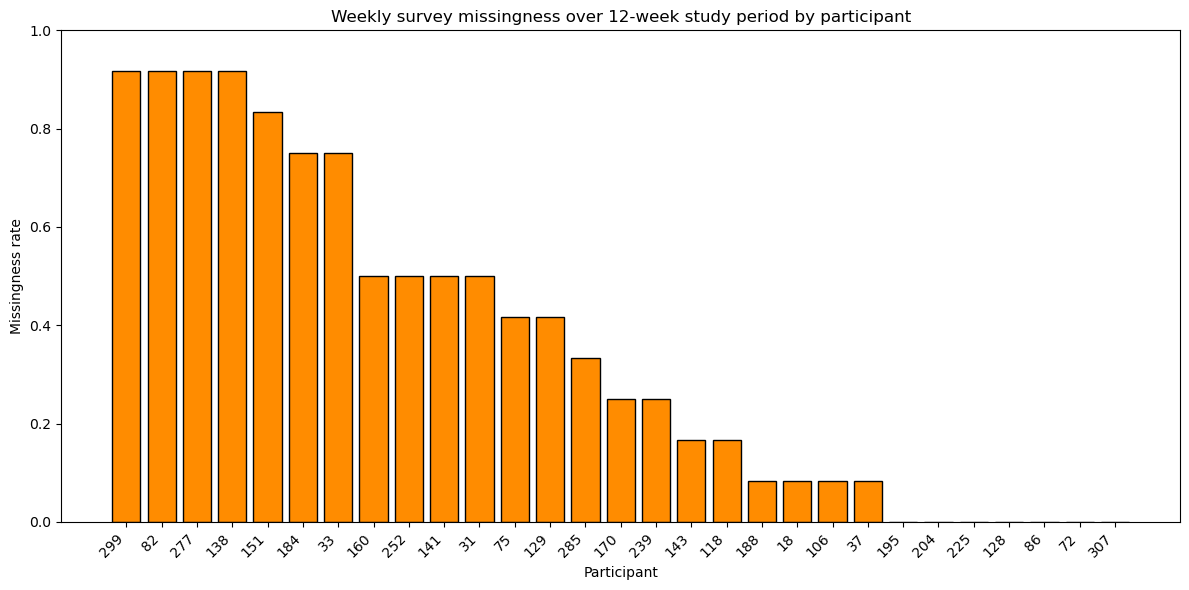

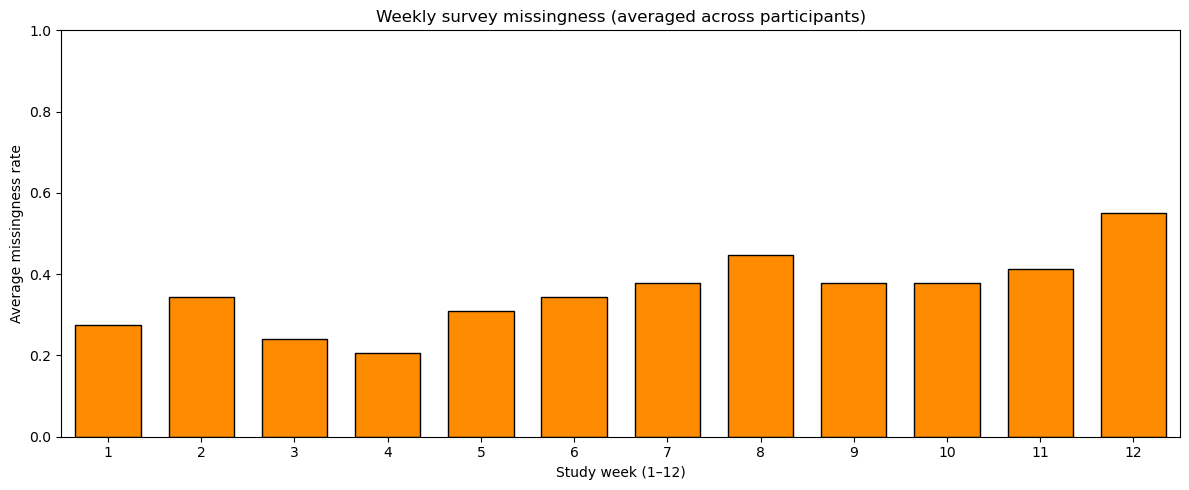

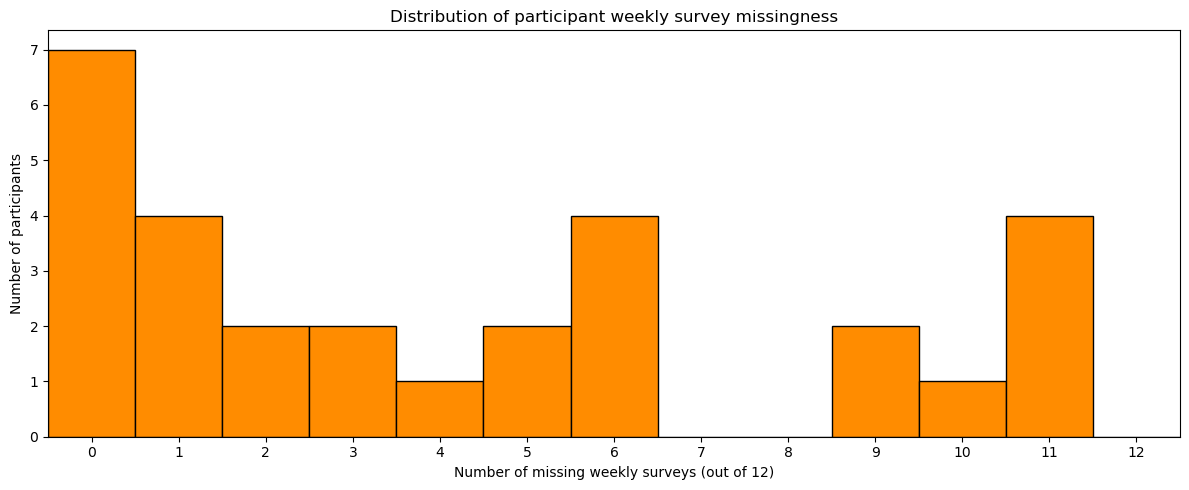

In [17]:
# 0.6 weekly survey missingness (12-week active phase)
# requires the import cell above
folder = '/Users/xueqingliu/Harvard University Dropbox/Liu Xueqing/ADAPT_MRT/Xueqing'
df_weekly_filled = pd.read_csv(os.path.join(folder, 'df_weekly_filled.csv'))

id_col = 'ParticipantIdentifier' if 'ParticipantIdentifier' in df_weekly_filled.columns else 'participantidentifier'

weekly = (
    df_weekly_filled.loc[df_weekly_filled['week'].between(1, 12)]
    .sort_values([id_col, 'week'])
    .copy()
)
weekly['missing_rate'] = 1 - weekly['week_present']

# --- plot 1: missingness rate per user over the whole 12-week period ---
user_weekly_miss = (
    weekly.groupby(id_col)['missing_rate']
    .mean()
    .sort_values(ascending=False)
)
participant_weekly_missing = weekly.groupby(id_col)['missing_rate'].sum()
week_miss = weekly.groupby('week', as_index=False)['missing_rate'].mean()

# --- summary statistics ---
print('=== Weekly survey missingness summary (12-week active phase) ===')
print(f'Participants: {user_weekly_miss.shape[0]}')
print(f'Overall missingness rate: {weekly["missing_rate"].mean():.1%}')
print()
print('Participant-level missingness rate:')
print(user_weekly_miss.describe().to_string())
print()
print('Number of missing weekly surveys per participant (out of 12):')
print(participant_weekly_missing.describe().to_string())
print()
print(f'Participants with 0% missingness: {(user_weekly_miss == 0).sum()}')
print(f'Participants with 100% missingness: {(user_weekly_miss == 1).sum()}')
print()
print('Week-averaged missingness across participants:')
print(week_miss['missing_rate'].describe().to_string())

fig, ax = plt.subplots(figsize=(12, 6))
x_pos = range(len(user_weekly_miss))
ax.bar(x_pos, user_weekly_miss.values, color='darkorange', edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(user_weekly_miss.index.astype(str), rotation=45, ha='right')
ax.set_xlabel('Participant')
ax.set_ylabel('Missingness rate')
ax.set_title('Weekly survey missingness over 12-week study period by participant')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

# --- plot 2: average missingness for each study week across participants ---

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(week_miss['week'], week_miss['missing_rate'], color='darkorange', edgecolor='black', width=0.7)
ax.set_xlabel('Study week (1–12)')
ax.set_ylabel('Average missingness rate')
ax.set_title('Weekly survey missingness (averaged across participants)')
ax.set_xticks(range(1, 13))
ax.set_xlim(0.5, 12.5)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

# --- plot 3: distribution of the number of missing surveys per participant ---

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(
    participant_weekly_missing,
    bins=np.arange(-0.5, 13.5, 1),
    color='darkorange',
    edgecolor='black',
)
ax.set_xlabel('Number of missing weekly surveys (out of 12)')
ax.set_ylabel('Number of participants')
ax.set_title('Distribution of participant weekly survey missingness')
ax.set_xticks(range(0, 13))
ax.set_xlim(-0.5, 12.5)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()


In [45]:
# 1. load the data
folder = '/Users/xueqingliu/Harvard University Dropbox/Liu Xueqing/ADAPT-MRT/completed_user_data'

# 1.1 load survey task
# there is also a file named surveyresults.csv, which does not seem to be very useful
# surveyname:
# status: Complete, Closed
# does Closed mean the survey is not completed? need to check out!!!
surveytask = pd.read_csv(os.path.join(folder, 'surveytasks.csv'))
# print(surveytask.head())

# 1.5 load survey question results
# survey task and survey question are linked by surveykey (surveytask.surveykey = surveyquestion.surveykey)
# but this does not distinguish between different days and different participants and different questions
# participantidentifier
# resultidentifier
# answers
# question_startdate
# question_enddate
surveyquestionresults = pd.read_csv(os.path.join(folder, 'surveyquestionresults.csv'))
# print(surveyquestionresults.head())


In [46]:
# check data types
print(surveytask.dtypes)
print(surveyquestionresults.dtypes)

surveytaskkey            object
participantidentifier     int64
surveykey                object
surveyname               object
status                   object
duedate                  object
inserteddate             object
createdby                object
modifieddate             object
participantid            object
_provenance              object
dtype: object
participantidentifier       int64
surveyresultkey            object
surveykey                  object
surveyversion               int64
surveyquestionresultkey    object
resultidentifier           object
questiontext               object
answerformat               object
answerchoices              object
answers                    object
question_startdate         object
question_enddate           object
dtype: object


In [47]:
unique_survey_names = surveytask.surveyname.unique()
print(unique_survey_names)

['MRT - Baseline survey 1' 'MRT - Baseline survey 2'
 'MRT - Personalize HeartSteps'
 'MRT - Long-term Goal Setting V2 w/ Carousel Images'
 'MRT - Daily End of day survey and Planning Exercise'
 'MRT - Weekly Check-in survey'
 'MRT - Monthly check-in survey and goal setting'
 'MRT - Walking Suggestions - Message Display'
 'MRT - Salience - Message Display'
 'MRT - Monthly check-in survey (Final month)']


In [48]:
# pick a specific participant
participant_id = 13

# check the survey results for this participant
survey_results_participant = surveyquestionresults[surveyquestionresults.participantidentifier == participant_id]

# check the survey task for this participant
survey_task_participant = surveytask[surveytask.participantidentifier == participant_id]

survey_task_participant_eod = survey_task_participant[survey_task_participant.surveyname == 'MRT - Daily End of day survey and Planning Exercise']
print(survey_task_participant_eod.head())

                          surveytaskkey  participantidentifier  \
4  C1ED80B5-554A-F011-AD1F-0E0E6A19462F                     13   
5  AACF5B7E-164B-F011-AD1F-0E0E6A19462F                     13   
6  FB8315F0-DF4B-F011-AD1F-0E0E6A19462F                     13   
7  0F9ACEEF-A84C-F011-AD1F-0E0E6A19462F                     13   
8  D489F9FF-714D-F011-AD1F-0E0E6A19462F                     13   

                              surveykey  \
4  A98012DB-67A3-EF11-BAFB-0AFFE8024CAD   
5  A98012DB-67A3-EF11-BAFB-0AFFE8024CAD   
6  A98012DB-67A3-EF11-BAFB-0AFFE8024CAD   
7  A98012DB-67A3-EF11-BAFB-0AFFE8024CAD   
8  A98012DB-67A3-EF11-BAFB-0AFFE8024CAD   

                                          surveyname    status  \
4  MRT - Daily End of day survey and Planning Exe...    Closed   
5  MRT - Daily End of day survey and Planning Exe...  Complete   
6  MRT - Daily End of day survey and Planning Exe...  Complete   
7  MRT - Daily End of day survey and Planning Exe...  Complete   
8  MRT - Daily

In [49]:
# get survey keys of the weekly, monthly and daily surveys
# print(survey_task_participant.head())
survey_key_weekly = survey_task_participant[survey_task_participant.surveyname == 'MRT - Weekly Check-in survey'].surveykey.values[0]
survey_key_monthly = survey_task_participant[survey_task_participant.surveyname == 'MRT - Monthly check-in survey and goal setting'].surveykey.values[0]
survey_key_last_monthly = survey_task_participant[survey_task_participant.surveyname == 'MRT - Monthly check-in survey (Final month)'].surveykey.values[0]
survey_key_daily = survey_task_participant[survey_task_participant.surveyname == 'MRT - Daily End of day survey and Planning Exercise'].surveykey.values[0]
# print(survey_key_weekly, survey_key_monthly, survey_key_last_monthly, survey_key_daily)

# transform survey keys to lowercase to match the surveyquestionresults.surveykey
survey_key_weekly = survey_key_weekly.lower()
survey_key_monthly = survey_key_monthly.lower()
survey_key_last_monthly = survey_key_last_monthly.lower()
survey_key_daily = survey_key_daily.lower()
# print(survey_key_weekly, survey_key_monthly, survey_key_last_monthly, survey_key_daily)

In [50]:
# check weekly survey results (should be 12 of which 3 are monthly)
len_weekly_survey = len(survey_results_participant[(survey_results_participant.surveykey == survey_key_weekly) & (survey_results_participant.resultidentifier == 'AffectiveValuation')])
len_monthly_survey = len(survey_results_participant[((survey_results_participant.surveykey == survey_key_monthly) | (survey_results_participant.surveykey == survey_key_last_monthly)) & (survey_results_participant.resultidentifier == 'AffectiveValuation')])
print(len_weekly_survey, len_monthly_survey)

print(survey_results_participant[(survey_results_participant.surveykey == survey_key_monthly) & (survey_results_participant.resultidentifier == 'AffectiveValuation')]) 
print(survey_results_participant[(survey_results_participant.surveykey == survey_key_weekly) & (survey_results_participant.resultidentifier == 'AffectiveValuation')]) 

# participant 13 has 9 weekly survey results and 2 monthly survey results
# missing 1 monthly survey result on 2025-09-08

len_daily_survey = len(survey_results_participant[(survey_results_participant.surveykey == survey_key_daily) & (survey_results_participant.resultidentifier == 'AffectiveReflection')])
print('len_daily_survey', len_daily_survey)

print(survey_results_participant[(survey_results_participant.surveykey == survey_key_daily) & (survey_results_participant.resultidentifier == 'AffectiveReflection')])

# participant 13 has 12 daily survey results
# missing 1 daily survey result on 2025-09-08
# participant 13 has 62 daily survey results
# missing 7*12 - 62 = 22 daily survey results

9 3
     participantidentifier                       surveyresultkey  \
368                     13  82e99509-3860-f011-ad1f-0e0e6a19462f   
682                     13  520a6695-9076-f011-ad1f-0affed0b5369   

                                surveykey  surveyversion  \
368  9015c191-c531-f011-ad1f-0e0e6a19462f             19   
682  9015c191-c531-f011-ad1f-0e0e6a19462f             19   

                  surveyquestionresultkey    resultidentifier  \
368  cce99509-3860-f011-ad1f-0e0e6a19462f  AffectiveValuation   
682  900a6695-9076-f011-ad1f-0affed0b5369  AffectiveValuation   

                           questiontext answerformat answerchoices answers  \
368  When I think about being active...   Scale, 0-7            {}     [6]   
682  When I think about being active...   Scale, 0-7            {}     [5]   

          question_startdate         question_enddate  
368  2025-07-13 22:21:15.000  2025-07-13 22:21:20.000  
682  2025-08-11 08:49:50.000  2025-08-11 08:49:57.000  
     partic

In [51]:
# check whether the status in survey task matches the survey results
len_complete_daily_survey = len(survey_task_participant[(survey_task_participant.status == 'Complete') & (survey_task_participant.surveyname == 'MRT - Daily End of day survey and Planning Exercise')])
print(len_complete_daily_survey)

len_complete_weekly_survey = len(survey_task_participant[(survey_task_participant.status == 'Complete') & (survey_task_participant.surveyname == 'MRT - Weekly Check-in survey')])
print(len_complete_weekly_survey)

len_complete_monthly_survey = len(survey_task_participant[(survey_task_participant.status == 'Complete') & ((survey_task_participant.surveyname == 'MRT - Monthly check-in survey and goal setting') | (survey_task_participant.surveyname == 'MRT - Monthly check-in survey (Final month)'))])
print(len_complete_monthly_survey)

# participant 13 has 9 complete weekly survey results and 2 complete monthly survey results
# missing 1 complete monthly survey result on 2025-09-08
# there is mismatch between the survey results and the survey task
# we should focus on the survey results



64
9
3


In [52]:
# list all resultidentifiers
print(survey_results_participant.resultidentifier.unique())

['Consent Nickname' 'Sex' 'Intro' 'preferredName' 'Weekday Bedtime'
 'Weekday Wakeup' 'Weekend Bedtime' 'Weekend Wakeup' 'intro-docky'
 'household-olderthan12' 'relationship' 'employment' 'age' 'household'
 'race' 'education' 'hispanic-latino' 'work-time' 'control-time'
 'work-location' 'tracker-usage' 'mHealth-usage-yes' 'phone-usage-times'
 'phone-usage-types' 'tech-comfort' 'mHealth-usage'
 'phone-usage-types-other' 'phone-comfort' 'calm-emotionallystable'
 'newexperiences-complex' 'sympathetic-warm' 'anxious-easilyupset'
 'disorganized-careless' 'dependable-selfdisciplined'
 'conventional-uncreative' 'extraverted-enthusiastic' 'reserved-quiet'
 'critical-quarrelsome' 'morning-evening-types' 'flexibility-withinday'
 'flexibility-dayofweek' 'flexibility-month' 'outro-docky'
 'exhausted-energized' 'failure-accomplishment'
 'group-enjoyable-notenjoyable' 'relaxing-stressful' 'feel-worse-better'
 'stimulating-boring' 'dread-lookforwardto' 'doctor-proud-shame'
 'tiring-invigorating' 'aft

In [53]:
# check 8 participants with missing survey results
participant_ids = [75, 72, 37, 22, 18, 31, 33, 13]

len_daily_surveys = []
len_weekly_surveys = []
len_monthly_surveys = []

for participant_id in participant_ids:
    survey_results_participant = surveyquestionresults[surveyquestionresults.participantidentifier == participant_id]
    len_daily_surveys.append(len(survey_results_participant[(survey_results_participant.surveykey == survey_key_daily) & (survey_results_participant.resultidentifier == 'AffectiveReflection')]))
    len_weekly_surveys.append(len(survey_results_participant[(survey_results_participant.surveykey == survey_key_weekly) & (survey_results_participant.resultidentifier == 'AffectiveValuation')]))
    len_monthly_surveys.append(len(survey_results_participant[((survey_results_participant.surveykey == survey_key_monthly) | (survey_results_participant.surveykey == survey_key_last_monthly)) & (survey_results_participant.resultidentifier == 'AffectiveValuation')]))

print(len_daily_surveys)
print(len_weekly_surveys)
print(len_monthly_surveys)

[11, 70, 71, 11, 51, 15, 12, 62]
[5, 9, 9, 5, 9, 3, 2, 9]
[2, 3, 2, 2, 3, 3, 2, 3]


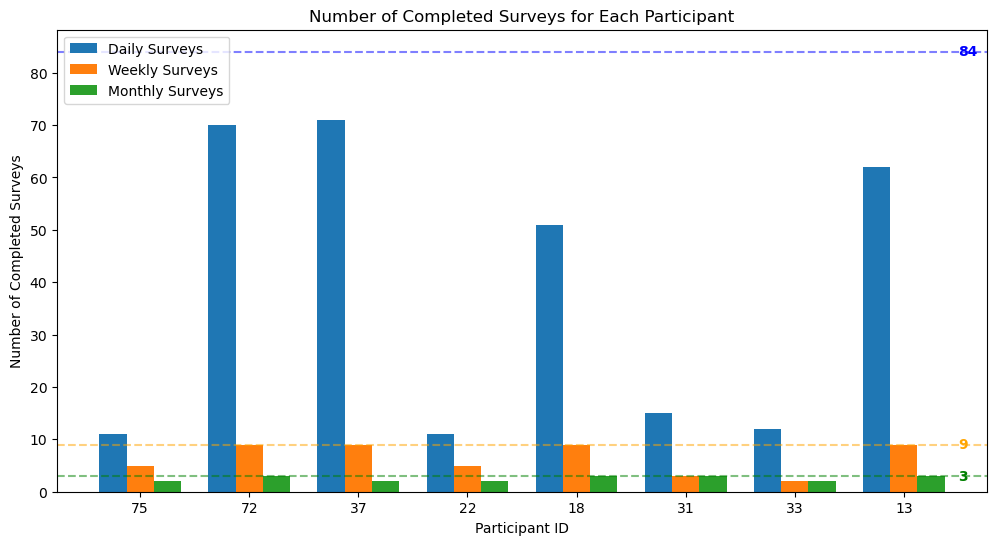

In [54]:
# plot histogram of the number of surveys for each participant
# x axis is the participant id, y axis is the number of surveys
x_pos = range(len(participant_ids))
width = 0.25  # Width of each bar

plt.figure(figsize=(12, 6))
plt.bar([x - width for x in x_pos], len_daily_surveys, width, label='Daily Surveys')
plt.bar(x_pos, len_weekly_surveys, width, label='Weekly Surveys')
plt.bar([x + width for x in x_pos], len_monthly_surveys, width, label='Monthly Surveys')
plt.xlabel('Participant ID')
plt.ylabel('Number of Completed Surveys')
plt.xticks(ticks=x_pos, labels=participant_ids)
plt.axhline(y=84, color='blue', linestyle='--', alpha=0.5)
plt.axhline(y=9, color='orange', linestyle='--', alpha=0.5)
plt.axhline(y=3, color='green', linestyle='--', alpha=0.5)
plt.text(len(participant_ids) - 0.5, 84, '84', va='center', ha='left', color='blue', fontweight='bold')
plt.text(len(participant_ids) - 0.5, 9, '9', va='center', ha='left', color='orange', fontweight='bold')
plt.text(len(participant_ids) - 0.5, 3, '3', va='center', ha='left', color='green', fontweight='bold')
plt.legend()
plt.title('Number of Completed Surveys for Each Participant')
plt.show()


In [55]:
# extract affective valuation from survey results (as numeric)
affective_valuations = []
for participant_id in participant_ids:
    survey_results_participant = surveyquestionresults[surveyquestionresults.participantidentifier == participant_id]
    vals = (survey_results_participant[survey_results_participant.resultidentifier == 'AffectiveValuation']['answers']
              .str.extract(r"(\d+)")[0]
              .astype(int)
              .to_numpy())
    affective_valuations.append(vals)

print(affective_valuations)



[array([6, 2, 5, 6, 5, 5, 5]), array([6, 7, 6, 6, 6, 6, 6, 6, 5, 5, 5, 6]), array([7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7]), array([3, 4, 4, 4, 4, 4, 4]), array([6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6]), array([5, 4, 6, 5, 5, 5]), array([5, 5, 5, 5]), array([5, 6, 5, 6, 5, 5, 5, 5, 5, 5, 5, 6])]


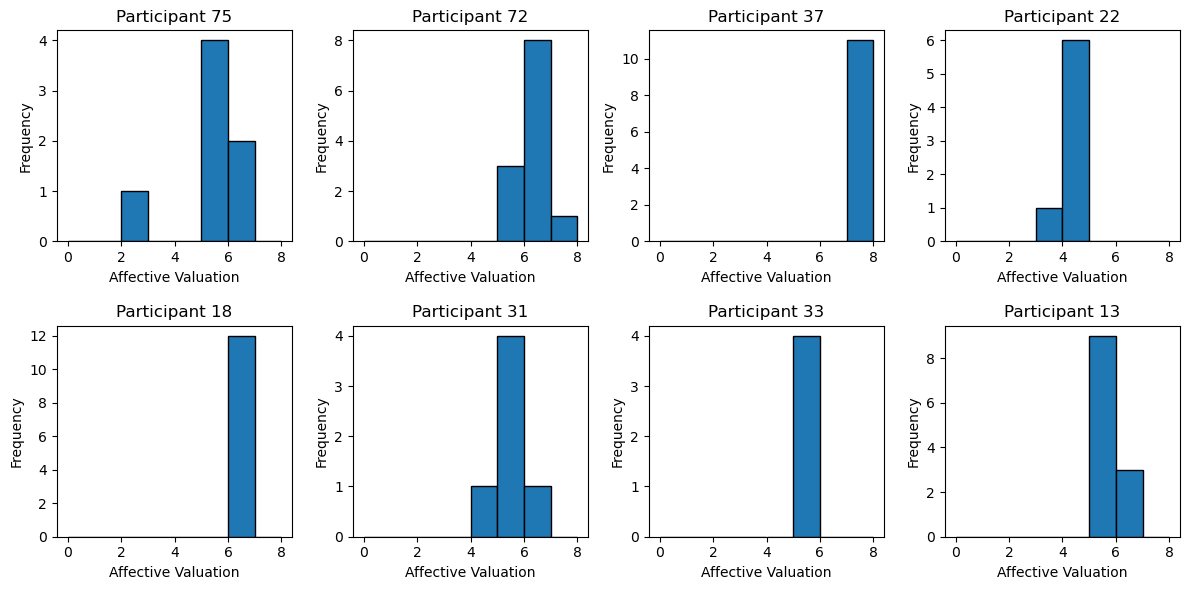

In [56]:
# plot histograms of affective valuation for each participant
plt.figure(figsize=(12, 6))
for i, participant_id in enumerate(participant_ids):
    plt.subplot(2, 4, i + 1)
    plt.hist(affective_valuations[i], bins=range(0, 9, 1), edgecolor='black')
    plt.title(f'Participant {participant_id}')
    plt.xlabel('Affective Valuation')
    plt.tight_layout(h_pad=1.5, w_pad=1.0)
    plt.ylabel('Frequency')

plt.show()

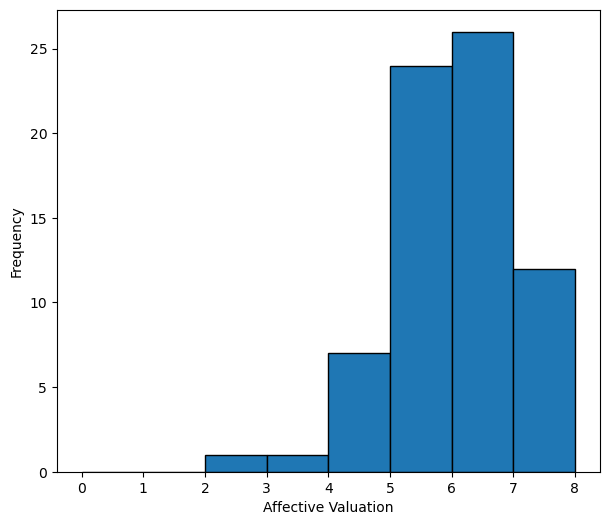

In [57]:
# plot histogram of affective valuation across all participants
affective_valuations_all = np.concatenate(affective_valuations)
plt.figure(figsize=(7, 6))
plt.hist(affective_valuations_all, bins=range(0, 9, 1), edgecolor='black')
plt.xlabel('Affective Valuation')
plt.ylabel('Frequency')
plt.show()


In [58]:
# extract perceived utility 1 from survey results (as numeric)
helpfulness = []
for participant_id in participant_ids:
    survey_results_participant = surveyquestionresults[surveyquestionresults.participantidentifier == participant_id]
    vals = (survey_results_participant[survey_results_participant.resultidentifier == 'Exp-tool-1']['answers']
              .str.extract(r"(\d+)")[0]
              .astype(int)
              .to_numpy())
    helpfulness.append(vals)

print(helpfulness)


[array([1, 2, 1, 2, 5, 5, 0]), array([5, 4, 4, 5, 5, 5, 5, 5, 4, 4, 4, 5]), array([4, 5, 7, 4, 5, 7, 7, 4, 3, 4, 4]), array([3, 5, 5, 5, 5, 4, 4]), array([5, 4, 5, 4, 5, 4, 5, 5, 5, 4, 4, 4]), array([3, 2, 1, 1, 3, 1]), array([6, 6, 6, 6]), array([5, 5, 5, 5, 5, 5, 4, 5, 4, 4, 4, 5])]


In [59]:
# extract perceived utility 2 from survey results (as numeric)
pleasantness = []
for participant_id in participant_ids:
    survey_results_participant = surveyquestionresults[surveyquestionresults.participantidentifier == participant_id]
    vals = (survey_results_participant[survey_results_participant.resultidentifier == 'Exp-tool-2']['answers']
              .str.extract(r"(\d+)")[0]
              .astype(int)
              .to_numpy())
    pleasantness.append(vals)

print(pleasantness)

[array([1, 1, 1, 2, 1, 5, 1]), array([6, 3, 3, 5, 5, 6, 5, 5, 5, 6, 5, 5]), array([5, 3, 4, 5, 6, 4, 4, 4, 4, 4, 4]), array([3, 5, 5, 4, 4, 4, 4]), array([4, 5, 4, 4, 4, 2, 4, 5, 5, 4, 4, 4]), array([3, 2, 3, 1, 3, 1]), array([5, 6, 5, 5]), array([5, 6, 6, 5, 6, 5, 4, 5, 4, 4, 4, 5])]


In [60]:
# combined perceived utility 1 and 2 (mean)
perceived_utility = []
perceived_utility = [(helpfulness[i] + pleasantness[i]) / 2 for i in range(len(participant_ids))]

print(perceived_utility)


[array([1. , 1.5, 1. , 2. , 3. , 5. , 0.5]), array([5.5, 3.5, 3.5, 5. , 5. , 5.5, 5. , 5. , 4.5, 5. , 4.5, 5. ]), array([4.5, 4. , 5.5, 4.5, 5.5, 5.5, 5.5, 4. , 3.5, 4. , 4. ]), array([3. , 5. , 5. , 4.5, 4.5, 4. , 4. ]), array([4.5, 4.5, 4.5, 4. , 4.5, 3. , 4.5, 5. , 5. , 4. , 4. , 4. ]), array([3., 2., 2., 1., 3., 1.]), array([5.5, 6. , 5.5, 5.5]), array([5. , 5.5, 5.5, 5. , 5.5, 5. , 4. , 5. , 4. , 4. , 4. , 5. ])]


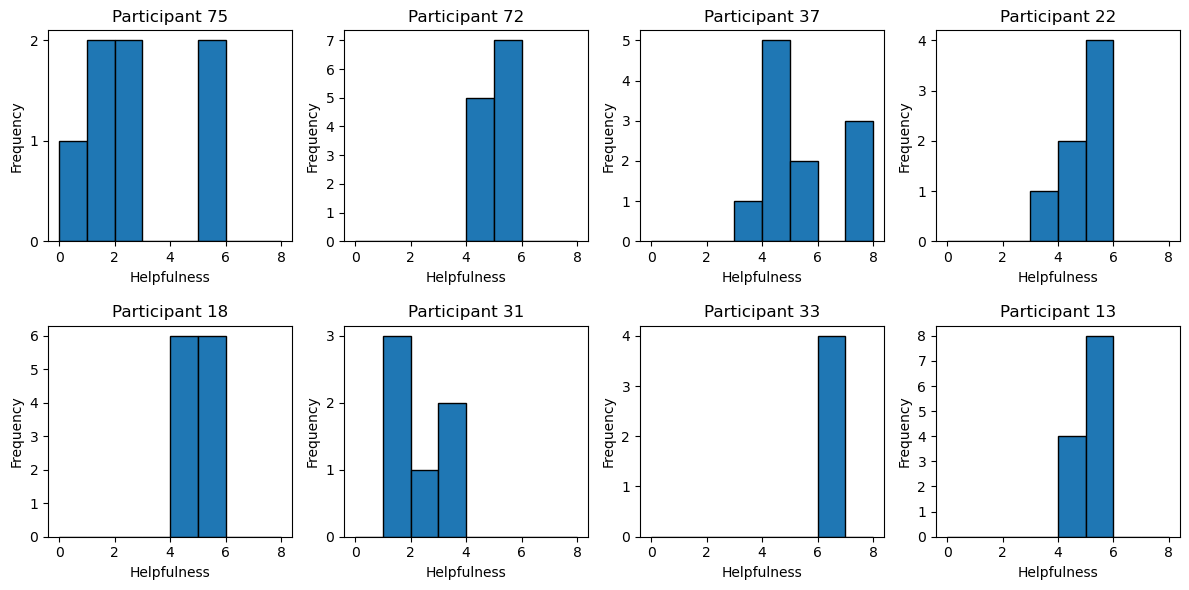

In [61]:
# plot histograms of helpfulness for each participant
plt.figure(figsize=(12, 6))
for i, participant_id in enumerate(participant_ids):
    ax = plt.subplot(2, 4, i + 1)
    ax.hist(helpfulness[i], bins=range(0, 9, 1), edgecolor='black')
    ax.set_title(f'Participant {participant_id}')
    ax.set_xlabel('Helpfulness')
    ax.set_ylabel('Frequency')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(h_pad=1.5, w_pad=1.0)
plt.show()

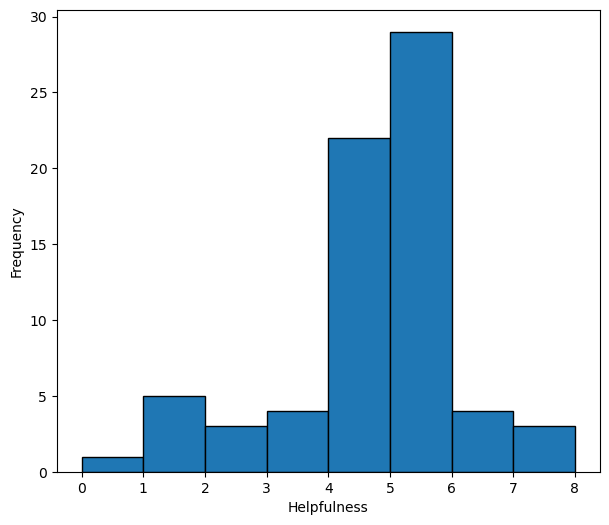

In [62]:
# plot histograms of helpfulness for all participants
helpfulness_all = np.concatenate(helpfulness)
plt.figure(figsize=(7, 6))
plt.hist(helpfulness_all, bins=range(0, 9, 1), edgecolor='black')
plt.xlabel('Helpfulness')
plt.ylabel('Frequency')
plt.show()


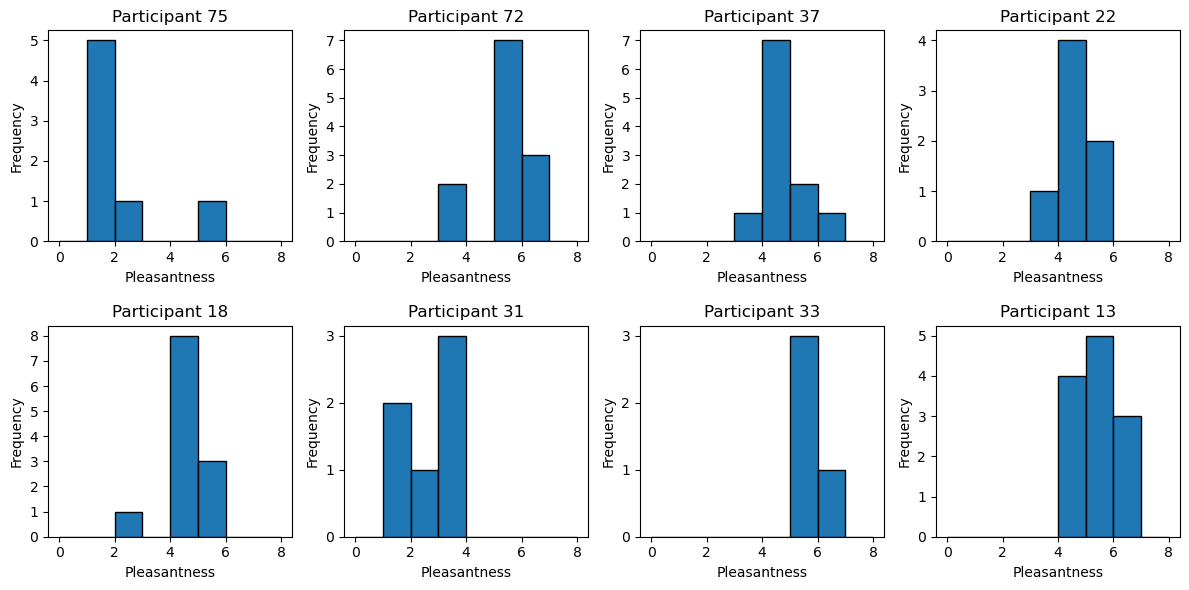

In [63]:
# plot histograms of helpfulness for each participant
plt.figure(figsize=(12, 6))
for i, participant_id in enumerate(participant_ids):
    ax = plt.subplot(2, 4, i + 1)
    ax.hist(pleasantness[i], bins=range(0, 9, 1), edgecolor='black')
    ax.set_title(f'Participant {participant_id}')
    ax.set_xlabel('Pleasantness')
    ax.set_ylabel('Frequency')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(h_pad=1.5, w_pad=1.0)
plt.show()

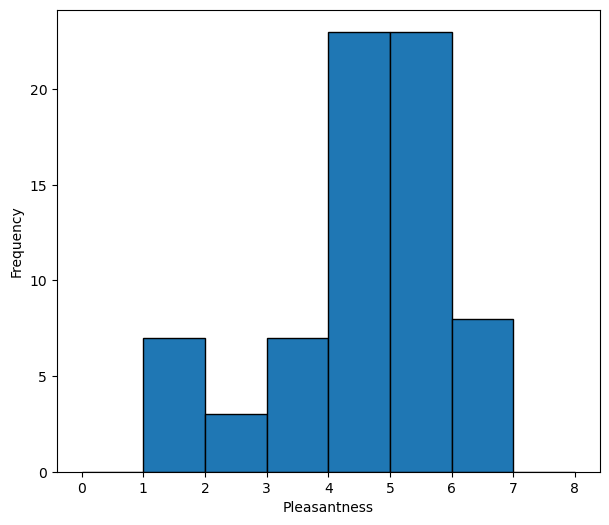

In [64]:
# plot histograms of pleasantness for all participants
pleasantness_all = np.concatenate(pleasantness)
plt.figure(figsize=(7, 6))
plt.hist(pleasantness_all, bins=range(0, 9, 1), edgecolor='black')
plt.xlabel('Pleasantness')
plt.ylabel('Frequency')
plt.show()

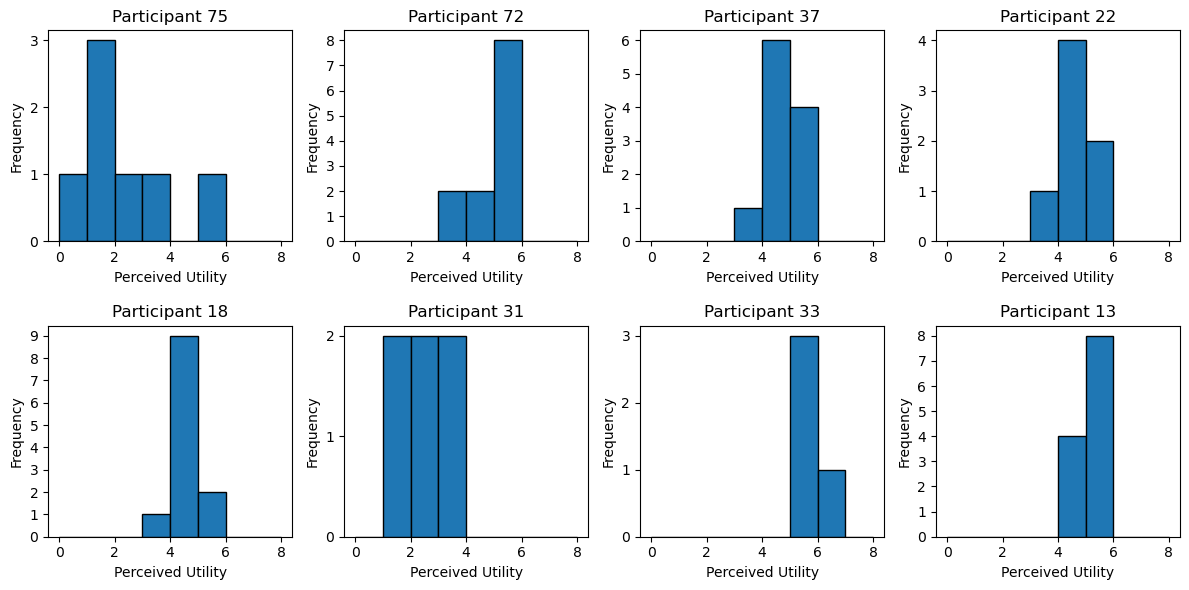

In [65]:
# plot histograms of perceived utility for each participant
plt.figure(figsize=(12, 6))
for i, participant_id in enumerate(participant_ids):
    ax = plt.subplot(2, 4, i + 1)
    ax.hist(perceived_utility[i], bins=range(0, 9, 1), edgecolor='black')
    ax.set_title(f'Participant {participant_id}')
    ax.set_xlabel('Perceived Utility')
    ax.set_ylabel('Frequency')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(h_pad=1.5, w_pad=1.0)
plt.show()

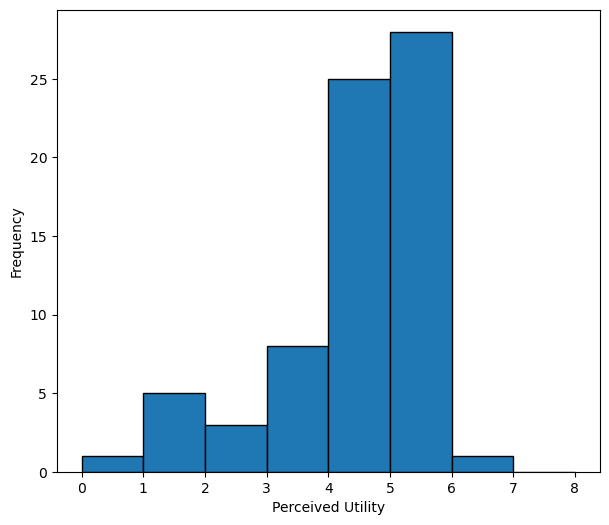

In [66]:
# plot histograms of perceived utility for all participants
perceived_utility_all = np.concatenate(perceived_utility)
plt.figure(figsize=(7, 6))
plt.hist(perceived_utility_all, bins=range(0, 9, 1), edgecolor='black')
plt.xlabel('Perceived Utility')
plt.ylabel('Frequency')
plt.show()

In [67]:
# extract affective reflection from daily survey results (as numeric)
affective_reflections = []
for participant_id in participant_ids:
    survey_results_participant = surveyquestionresults[surveyquestionresults.participantidentifier == participant_id]
    vals = (survey_results_participant[survey_results_participant.resultidentifier == 'AffectiveReflection']['answers']
              .str.extract(r"(\d+)")[0]
              .astype(int)
              .to_numpy())
    affective_reflections.append(vals)
print(affective_reflections)

[array([5, 5, 5, 5, 2, 5, 6, 5, 6, 6, 6]), array([5, 5, 6, 6, 5, 6, 5, 6, 6, 6, 5, 5, 5, 6, 5, 5, 6, 5, 6, 6, 6, 6,
       6, 5, 6, 6, 5, 6, 7, 6, 5, 6, 5, 6, 6, 6, 4, 5, 6, 6, 6, 5, 5, 6,
       6, 5, 6, 5, 5, 5, 6, 6, 5, 6, 5, 5, 6, 6, 5, 6, 6, 7, 7, 5, 6, 6,
       6, 6, 6, 6]), array([7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7]), array([4, 2, 5, 5, 5, 6, 4, 5, 4, 4, 5]), array([6, 6, 6, 6, 6, 6, 5, 6, 6, 7, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 5, 6, 6, 6]), array([5, 7, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 5]), array([5, 5, 6, 5, 4, 6, 6, 5, 5, 4, 6, 6]), array([6, 5, 6, 6, 6, 5, 5, 5, 6, 6, 2, 5, 7, 6, 7, 7, 6, 6, 6, 6, 6, 5,
       6, 6, 6, 6, 6, 6, 6, 5, 6, 6, 6, 5, 6, 6, 5, 6, 5, 5, 6, 6, 6, 5,
       6, 7

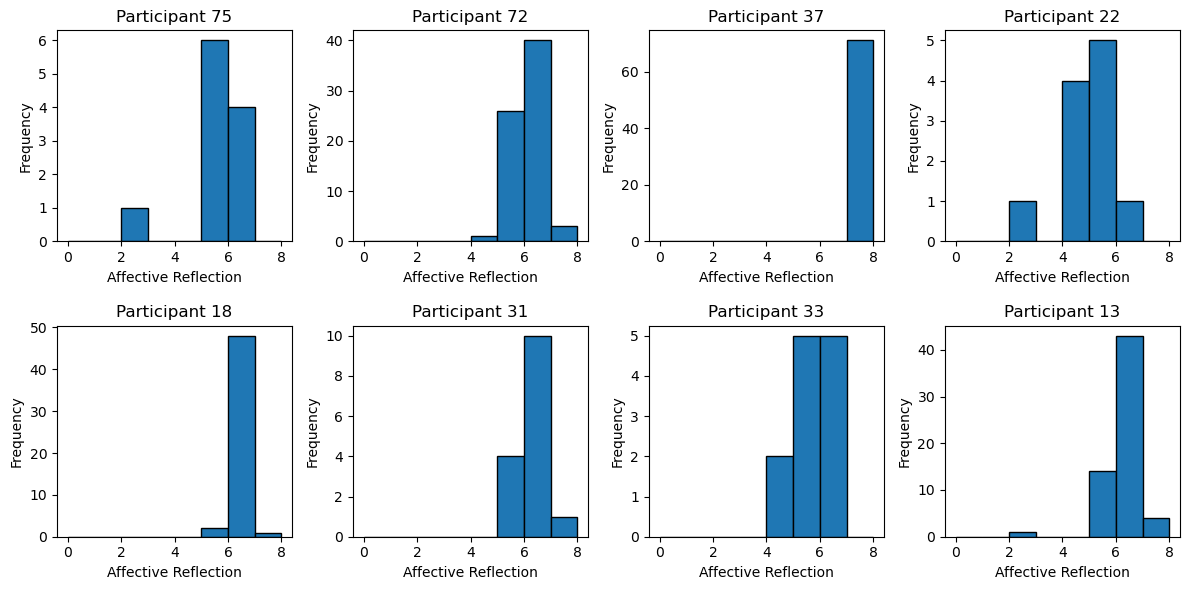

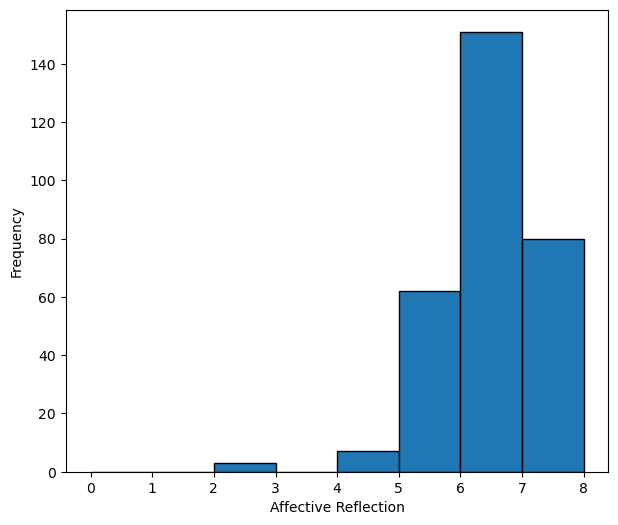

In [68]:
# plot histograms of affective reflection for each participant
plt.figure(figsize=(12, 6))
for i, participant_id in enumerate(participant_ids):
    plt.subplot(2, 4, i + 1)
    plt.hist(affective_reflections[i], bins=range(0, 9, 1), edgecolor='black')
    plt.title(f'Participant {participant_id}')
    plt.xlabel('Affective Reflection')
    plt.ylabel('Frequency')
    plt.tight_layout(h_pad=1.5, w_pad=1.0)
plt.show()
# plot histograms of affective reflection for all participants
plt.figure(figsize=(7, 6))
plt.hist(np.concatenate(affective_reflections), bins=range(0, 9, 1), edgecolor='black')
plt.xlabel('Affective Reflection')
plt.ylabel('Frequency')
plt.show()
    

In [69]:
# extract anticipated affect from daily survey results (as numeric)
anticipated_affects = []
for participant_id in participant_ids:
    survey_results_participant = surveyquestionresults[surveyquestionresults.participantidentifier == participant_id]
    vals = (survey_results_participant[survey_results_participant.resultidentifier == 'AnticipatedAffect']['answers']
              .str.extract(r"(\d+)")[0]
              .astype(int)
              .to_numpy())
    anticipated_affects.append(vals)
print(anticipated_affects)


[array([4, 5, 5, 5, 2, 5, 6, 5, 6, 6, 6]), array([5, 4, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6,
       5, 5, 5, 5, 5, 6, 5, 5, 6, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 6, 6,
       5, 6, 6, 5, 5, 6, 5, 5, 6, 6, 6, 5, 6, 5, 6, 6, 6, 6, 6, 7, 5, 7,
       6, 6, 5, 6, 6, 6]), array([7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7]), array([4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]), array([6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6]), array([6, 5, 6, 7, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 5, 6, 6]), array([6, 5, 6, 5, 6, 6, 5, 6, 6, 6, 6, 5, 6, 6]), array([6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 6, 6, 7, 7, 7, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,

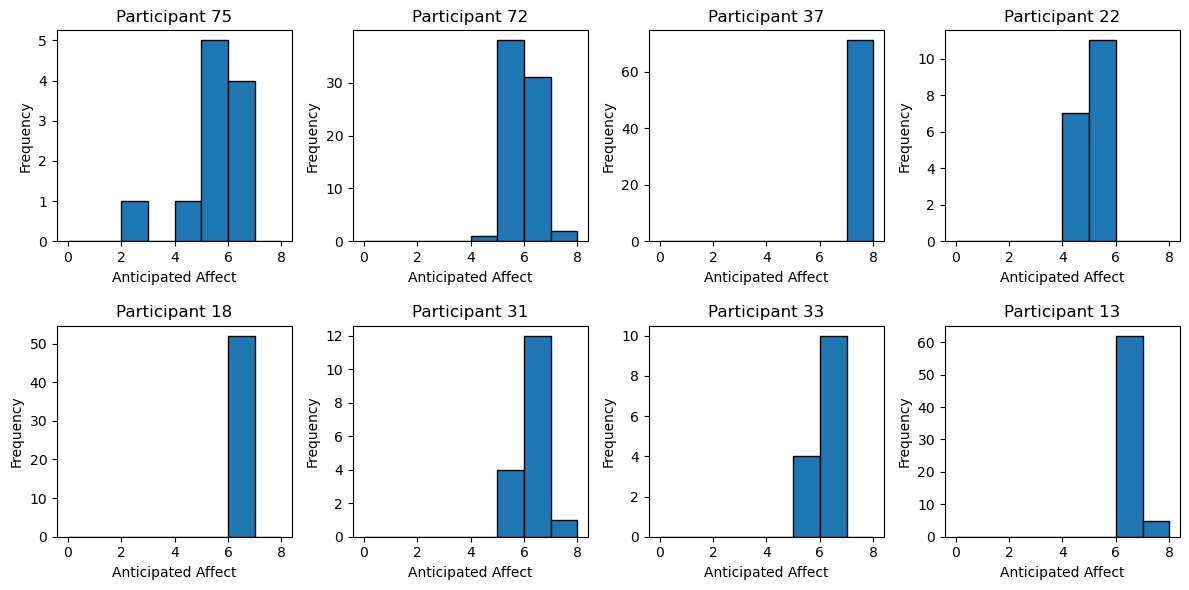

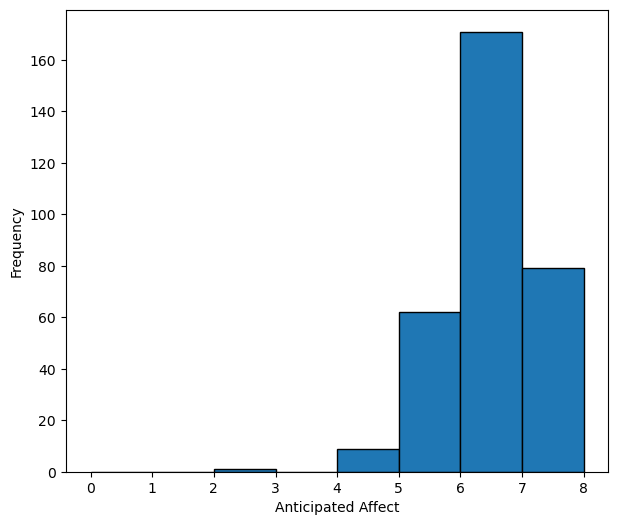

In [70]:
# plot histograms of anticipated affect for each participant
plt.figure(figsize=(12, 6))
for i, participant_id in enumerate(participant_ids):
    plt.subplot(2, 4, i + 1)
    plt.hist(anticipated_affects[i], bins=range(0, 9, 1), edgecolor='black')
    plt.title(f'Participant {participant_id}')
    plt.xlabel('Anticipated Affect')
    plt.ylabel('Frequency')
    plt.tight_layout(h_pad=1.5, w_pad=1.0)
plt.show()
# plot histograms of anticipated affect for all participants
plt.figure(figsize=(7, 6))
plt.hist(np.concatenate(anticipated_affects), bins=range(0, 9, 1), edgecolor='black')
plt.xlabel('Anticipated Affect')
plt.ylabel('Frequency')
plt.show()



## Get wakeup and bedtime from fitbit physical activity data
* or maybe not wakeup and bedtime but rather 

In [71]:
# read step count data by minute
stepcountbymin = pd.read_csv(os.path.join(folder, 'stepcountbymin.csv'))
stepcountbymin.head()


,participantidentifier,type,datetime,value,level,mets,coverage,rmssd,hf,lf,deepsleepsummarybreathrate,remsleepsummarybreathrate,fullsleepsummarybreathrate,lightsleepsummarybreathrate,inserteddate
0,13,activities-steps,2025-06-03 00:00:00.000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-06-04 20:56:47.000
1,13,activities-steps,2025-06-03 00:01:00.000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-06-04 20:56:47.000
2,13,activities-steps,2025-06-03 00:02:00.000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-06-04 20:56:47.000
3,13,activities-steps,2025-06-03 00:03:00.000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-06-04 20:56:47.000
4,13,activities-steps,2025-06-03 00:04:00.000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-06-04 20:56:47.000


In [72]:
# for the active phase, we require 12*7 = 84 days of step count data
stepcountbymin['datetime'] = pd.to_datetime(stepcountbymin['datetime'])
stepcountbymin['date'] = stepcountbymin['datetime'].dt.date

summary = (
    stepcountbymin
    .groupby('participantidentifier')['date']
    .agg(date_min='min', date_max='max', n_days='nunique')
    .assign(span_days=lambda df: (pd.to_datetime(df.date_max) -
                                  pd.to_datetime(df.date_min)).dt.days + 1)
)



# make participantidentifier a column name
summary.reset_index(inplace=True)
summary.rename(columns={'participantidentifier': 'participantidentifier'}, inplace=True)

print(summary)

   participantidentifier    date_min    date_max  n_days  span_days
0                     13  2025-06-03  2025-09-09      99         99
1                     18  2025-06-18  2025-09-24      97         99
2                     22  2025-06-21  2025-09-19      91         91
3                     31  2025-06-24  2025-09-28      97         97
4                     33  2025-05-14  2025-10-08     146        148
5                     37  2025-06-04  2025-11-05     152        155
6                     72  2025-07-14  2025-10-18      97         97
7                     75  2025-06-11  2025-10-29     141        141


In [73]:
# check whether the record of step count start date is the same as the baseline survey date
surveytask['date'] = pd.to_datetime(surveytask['inserteddate']).dt.date
# survey_task_active = surveytask[surveytask.surveyname == 'MRT - Salience - Message Display']
survey_task_active = surveytask[surveytask.surveyname == 'MRT - Daily End of day survey and Planning Exercise']
summary_surveytask = (
    survey_task_active
    .groupby('participantidentifier')['date']
    .agg(date_min='min', date_max='max', n_days='nunique')
    .assign(span_days=lambda df: (pd.to_datetime(df.date_max) -
                                  pd.to_datetime(df.date_min)).dt.days + 1)
)


# make participantidentifier a column name
summary_surveytask.reset_index(inplace=True)
summary_surveytask.rename(columns={'participantidentifier': 'participantidentifier'}, inplace=True)

print(summary_surveytask)


   participantidentifier    date_min    date_max  n_days  span_days
0                     13  2025-06-16  2025-09-10      80         87
1                     18  2025-06-30  2025-09-21      81         84
2                     22  2025-06-30  2025-09-21      75         84
3                     31  2025-07-07  2025-09-28      83         84
4                     33  2025-06-30  2025-09-21      82         84
5                     37  2025-07-14  2025-10-05      83         84
6                     72  2025-07-27  2025-10-19      85         85
7                     75  2025-07-27  2025-10-19      85         85


In [74]:
# make sure the date_min of survey is later than the date_min of step count
print(summary_surveytask[summary_surveytask.date_min < summary.date_min])


Empty DataFrame
Columns: [participantidentifier, date_min, date_max, n_days, span_days]
Index: []


In [75]:
# check the surveyquestionresults
surveyquestionresults['date'] = pd.to_datetime(surveyquestionresults['question_startdate']).dt.date
surveyquestionresults_active = surveyquestionresults[surveyquestionresults.surveykey == survey_key_daily]
summary_surveyquestionresults = (
    surveyquestionresults_active
    .groupby('participantidentifier')['date']
    .agg(date_min='min', date_max='max', n_days='nunique')
    .assign(span_days=lambda df: (pd.to_datetime(df.date_max) -
                                  pd.to_datetime(df.date_min)).dt.days + 1)
)



# make participantidentifier a column name
summary_surveyquestionresults.reset_index(inplace=True)
summary_surveyquestionresults.rename(columns={'participantidentifier': 'participantidentifier'}, inplace=True)

print(summary_surveyquestionresults)
# make sure the date_min of survey is later than the date_min of step count
print(summary_surveyquestionresults[summary_surveyquestionresults.date_min < summary.date_min])


   participantidentifier    date_min    date_max  n_days  span_days
0                     13  2025-06-17  2025-09-11      65         87
1                     18  2025-07-20  2025-09-21      44         64
2                     22  2025-07-01  2025-09-21      21         83
3                     31  2025-07-09  2025-09-14      16         68
4                     33  2025-07-22  2025-08-15      12         25
5                     37  2025-07-14  2025-10-06      59         85
6                     72  2025-07-28  2025-10-20      68         85
7                     75  2025-08-15  2025-10-12      11         59
Empty DataFrame
Columns: [participantidentifier, date_min, date_max, n_days, span_days]
Index: []


In [76]:
# start from the active survey date 
# read the projectdevice data
projectdevice = pd.read_csv(os.path.join(folder, 'projectdevice.csv'))
# print(projectdevice.head())

print(projectdevice.type.unique())



['within-day-goal-check' 'fitbit-updater' 'newday-update-goals-n-averages'
 'fitbit-wear-time-adherence' 'walking-suggestions' 'salience-messages'
 'end-of-day-survey' 'adherence-escalation-check' 'midweek-checkin'
 'monday-step-count-reset' 'notification-task-reset'
 'check-pause-expiration']


## Get wakeup times and bedtimes for each user

- we currently get these from the baseline survey


In [77]:
# get baseline surveykey
# survey_key_baseline = surveytask[surveytask.surveyname == 'MRT - Personalize HeartSteps'].surveykey.values[0]

# get wakeup and bedtime for each user
# key fields: resultidentifier: Wakeday Wakeup, Wakeday Bedtime, Weekend Wakeup, Weekend Bedtime
weekday_wakeup_all = []
weekday_bedtime_all = []
weekend_wakeup_all = []
weekend_bedtime_all = []

question_enddate_all = []

for participant_id in participant_ids:
    subset = surveyquestionresults[surveyquestionresults.participantidentifier == participant_id]

    wake_weekday = (
        subset[subset.resultidentifier == 'Weekday Wakeup']['answers']
        .str.strip('[]')
        .pipe(pd.to_datetime, format='%I:%M %p', errors='coerce')
    )
    weekday_wakeup_all.append(wake_weekday.dt.time.to_list())

    question_enddate = (
        subset[subset.resultidentifier == 'Weekday Wakeup']['question_enddate']
        .pipe(pd.to_datetime, errors='coerce')
    )
    question_enddate_all.append(question_enddate.dt.date.to_list())

    bed_weekday = (
        subset[subset.resultidentifier == 'Weekday Bedtime']['answers']
        .str.strip('[]')
        .pipe(pd.to_datetime, format='%I:%M %p', errors='coerce')
    )
    weekday_bedtime_all.append(bed_weekday.dt.time.to_list())

    wake_weekend = (
        subset[subset.resultidentifier == 'Weekend Wakeup']['answers']
        .str.strip('[]')
        .pipe(pd.to_datetime, format='%I:%M %p', errors='coerce')
    )
    weekend_wakeup_all.append(wake_weekend.dt.time.to_list())

    bed_weekend = (
        subset[subset.resultidentifier == 'Weekend Bedtime']['answers']
        .str.strip('[]')
        .pipe(pd.to_datetime, format='%I:%M %p', errors='coerce')
    )
    weekend_bedtime_all.append(bed_weekend.dt.time.to_list())       

from itertools import zip_longest

rows = []
for pid, time1s, time2s, time3s, time4s, dates in zip(participant_ids, weekday_wakeup_all, weekday_bedtime_all, weekend_wakeup_all, weekend_bedtime_all, question_enddate_all):
    # zip_longest lets you handle mismatched lengths
    for time1, time2, time3, time4, date in zip_longest(time1s, time2s, time3s, time4s, dates):
        rows.append({
            'participantidentifier': pid,
            'weekday_wakeup': time1,
            'weekday_bedtime': time2,
            'weekend_wakeup': time3,
            'weekend_bedtime': time4,
            'date': date,
        })

df_wakeup_bedtime = pd.DataFrame(rows)
print(df_wakeup_bedtime)

    participantidentifier weekday_wakeup weekday_bedtime weekend_wakeup  \
0                      75       08:00:00        23:00:00       08:00:00   
1                      72       07:00:00        22:30:00       08:30:00   
2                      37       07:00:00        22:00:00       19:00:00   
3                      22       07:12:00        11:00:00       09:00:00   
4                      18       07:30:00        22:20:00       08:00:00   
5                      18       07:30:00        22:30:00       08:00:00   
6                      18       07:30:00        22:10:00       08:00:00   
7                      18       07:30:00        21:20:00       08:00:00   
8                      31       07:00:00        22:00:00       08:00:00   
9                      33       06:00:00        23:00:00       07:00:00   
10                     13       07:30:00        23:00:00       08:00:00   

   weekend_bedtime        date  
0         23:00:00  2025-07-11  
1         22:30:00  2025-07-09  


In [78]:
df = projectdevice.copy()

def parse_value(s):
    try:
        return json.loads(s)
    except (TypeError, json.JSONDecodeError):
        return {}

df['value_parsed'] = df['value'].apply(parse_value)

def list_keys(records):
    key_sets = []
    for r in records:
        if isinstance(r, dict):
            key_sets.append(tuple(sorted(r.keys())))
    return pd.Series(key_sets).value_counts()

for t, group in df.groupby('type'):
    print(f"\n=== type: {t} ===")
    keys_counts = list_keys(group['value_parsed'])
    print(keys_counts.head(5))


=== type: adherence-escalation-check ===
(event, name, steps, user)    725
Name: count, dtype: int64

=== type: check-pause-expiration ===
(event, name, steps, user)    12
Name: count, dtype: int64

=== type: end-of-day-survey ===
(event, name, steps, user)    672
Name: count, dtype: int64

=== type: fitbit-updater ===
(event, name, steps, user)    77715
Name: count, dtype: int64

=== type: fitbit-wear-time-adherence ===
(event, name, steps, user)    698
Name: count, dtype: int64

=== type: midweek-checkin ===
(event, name, steps, user)    96
Name: count, dtype: int64

=== type: monday-step-count-reset ===
(event, name, steps, user)    97
Name: count, dtype: int64

=== type: newday-update-goals-n-averages ===
(event, name, steps, user)    856
Name: count, dtype: int64

=== type: notification-task-reset ===
(event, name, steps, user)    47
Name: count, dtype: int64

=== type: salience-messages ===
(event, name, steps, user)    671
Name: count, dtype: int64

=== type: walking-suggestion

In [79]:
for t, group in df.groupby('type'):
    norm = pd.json_normalize(group['value_parsed'], sep='.')
    print(f"\n=== type: {t} ===")
    print(norm.columns)


=== type: adherence-escalation-check ===
Index(['name', 'steps', 'event.eventType', 'event.name', 'event.procedures',
       'event.timestamp', 'event.eventDetails.timestamp', 'event.id',
       'user.id', 'user.enrolled', 'user.invitationStatus',
       'user.insertedDate', 'user.enrollmentDate', 'user.withdrawDate',
       'user.viewParticipantRecordLink', 'user.accountEmail',
       'user.accountMobilePhone', 'user.participantIdentifier',
       'user.linkIdentifier', 'user.demographics.email',
       'user.demographics.mobilePhone', 'user.demographics.firstName',
       'user.demographics.lastName', 'user.demographics.utcOffset',
       'user.demographics.unsubscribedFromEmails',
       'user.demographics.unsubscribedFromSms', 'user.demographics.timeZone',
       'user.customFields.StepsAverageLastWeek',
       'user.customFields.ActivatedDate', 'user.customFields.Age',
       'user.customFields.AlreadyReceivedGifNotifications',
       'user.customFields.AlreadyReceivedSalienceNot

In [80]:
#
# Pull the nested customFields if present
df['activated_date'] = (
    df['value_parsed']
      .apply(lambda v: v.get('user', {}).get('customFields', {}).get('ActivatedDate'))
)

# More robust extraction - handle the 2 list values
def extract_activation_date(val):
    """Extract activation date from various nested structures"""
    # Check for None first
    if val is None:
        return None
    
    # Check if it's a string
    if isinstance(val, str):
        return val
    
    # If it's a list, unwrap it
    if isinstance(val, list):
        if len(val) == 0:
            return None
        # Recursively unwrap
        return extract_activation_date(val[0])
    
    # For any other type (like numpy types), try to return as-is
    try:
        # Check if it's actually NaN/None
        if pd.isna(val):
            return None
    except (ValueError, TypeError):
        pass
    
    return val

# Apply the extraction to handle those 2 list values
df['activated_date'] = df['activated_date'].apply(extract_activation_date)

# just check to make sure the activated_date is constant for each participant
print(df.activated_date.unique())


# extract the activated date from the projectdevice data for each participant
activated = (
    df[['participantidentifier', 'activated_date']]
      .dropna(subset=['activated_date'])
      .drop_duplicates(subset=['participantidentifier'], keep='last')
      .copy()
)

print("Activated dates:")
print(activated)
print(f"\nDate range: {activated['activated_date'].min()} to {activated['activated_date'].max()}")

['2025-06-15T00:00:00.000Z' None '2025-06-29T00:00:00.000Z'
 '2025-07-06T00:00:00.000Z' '2025-07-13T00:00:00.000Z'
 '2025-07-27T00:00:00.000Z']
Activated dates:
        participantidentifier            activated_date
19399                      13  2025-06-15T00:00:00.000Z
37416                      18  2025-06-29T00:00:00.000Z
55429                      22  2025-06-29T00:00:00.000Z
74333                      31  2025-07-06T00:00:00.000Z
92603                      33  2025-06-29T00:00:00.000Z
110427                     37  2025-07-13T00:00:00.000Z
128828                     72  2025-07-27T00:00:00.000Z
147054                     75  2025-07-27T00:00:00.000Z

Date range: 2025-06-15T00:00:00.000Z to 2025-07-27T00:00:00.000Z


In [81]:
# extract user.customFields.ExitDate in a similar way
df['exit_date'] = (
    df['value_parsed']
      .apply(lambda x: x.get('user', {}).get('customFields', {}).get('ExitDate'))
)

df['exit_date'] = df['exit_date'].apply(extract_activation_date)

print(df.exit_date.unique())

# extract exit date from the projectdevice data for each participant
exit = (
    df[['participantidentifier', 'exit_date']]
      .dropna(subset=['exit_date'])
      # .drop_duplicates(subset=['participantidentifier'], keep='last')
      .copy()
)

print("Exit dates:")
print(exit)
print(f"\nDate range: {exit['exit_date'].min()} to {exit['exit_date'].max()}")


[None '2025-09-21T00:00:00.000Z' '2025-09-27T00:00:00.000Z'
 '2025-09-26T00:00:00.000Z' '2025-09-28T00:00:00.000Z']
Exit dates:
       participantidentifier                 exit_date
33262                     18  2025-09-21T00:00:00.000Z
34706                     18  2025-09-27T00:00:00.000Z
78900                     33  2025-09-26T00:00:00.000Z
80706                     33  2025-09-28T00:00:00.000Z
84126                     33  2025-09-26T00:00:00.000Z
84130                     33  2025-09-28T00:00:00.000Z
90372                     33  2025-09-26T00:00:00.000Z
90648                     33  2025-09-21T00:00:00.000Z

Date range: 2025-09-21T00:00:00.000Z to 2025-09-28T00:00:00.000Z


In [82]:
# using heartrate to define drop out...etc
heartratebymin = pd.read_csv(os.path.join(folder, 'heartratebymin.csv'))
print(heartratebymin.head())

## TODO:   
# 1. get the active survey date
# 2. ignore data after 84 days of active survey date
# 3. calculate the last day of having at least 8 hours of heart rate data, and the rest are drop out
# 

   participantidentifier                 datetime  heart_rate
0                     13  2025-06-04 07:50:13.000       129.0
1                     13  2025-06-04 07:50:15.000       132.0
2                     13  2025-06-04 07:50:17.000       127.0
3                     13  2025-06-04 07:50:19.000       102.0
4                     13  2025-06-04 07:50:21.000       108.0


## Extract hourly step count
* I'm using the daily survey start and end date as a reference for looking at daily step counts
* I also used activated data from project device data to filter fitbit step counts, which matches the daily survey start date!!!  
* I haven't considered any dropouts for during the study for now...


In [83]:
# Select date range based on daily survey start and end date
stepcountbymin_selected = []
for participant_id in participant_ids:
    stepcountbymin_participant = stepcountbymin[stepcountbymin['participantidentifier'] == participant_id]
    summary_row = summary_surveytask.loc[
        summary_surveytask['participantidentifier'] == participant_id
    ].iloc[0]  # assumes one row per participant

    start_date = summary_row.date_min
    end_date = summary_row.date_max
    stepcountbymin_participant = stepcountbymin_participant[stepcountbymin_participant.date >= start_date]
    stepcountbymin_participant = stepcountbymin_participant[stepcountbymin_participant.date <= end_date]
    stepcountbymin_selected.append(stepcountbymin_participant)

stepcountbymin_selected = pd.concat(stepcountbymin_selected)
stepcountbymin_selected = stepcountbymin_selected[["participantidentifier", "datetime", "value"]]
print(stepcountbymin_selected.head())
    

         participantidentifier            datetime  value
1586508                     75 2025-07-27 00:00:00    0.0
1586509                     75 2025-07-27 00:00:00    0.0
1586510                     75 2025-07-27 00:01:00    0.0
1586511                     75 2025-07-27 00:01:00    0.0
1586512                     75 2025-07-27 00:02:00    0.0


In [84]:

# Ensure datetime column is parsed
participant_id = 13

# Work with date-only column for grouping
# grouped = stepcountbymin.groupby(stepcountbymin['datetime'].dt.date)

# One combined figure with multiple lines (one per date)
# plt.figure(figsize=(12, 6))
# participant_data = stepcountbymin_selected[stepcountbymin_selected['participantidentifier'] == participant_id]
# for date, df_day in participant_data.groupby(participant_data['datetime'].dt.date):
#     plt.figure(figsize=(10, 4))
#     plt.plot(df_day['datetime'], df_day['value'])
#     plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
#     plt.title(f'Participant {participant_id} – {date}')
#     plt.xlabel('Time of Day')
#     plt.ylabel('Step Count')
#     plt.tight_layout()
#     plt.show()


In [85]:
# get the step count start time for each participant
print(df_wakeup_bedtime)
prop_list = []
avg_start_time_list = []
avg_end_time_list = []
for participant_id in participant_ids:
    stepcountbymin_participant = stepcountbymin_selected[stepcountbymin_selected['participantidentifier'] == participant_id]
    # merge same datetime
    stepcountbymin_participant = (
    stepcountbymin_selected
      .loc[stepcountbymin_selected['participantidentifier'] == participant_id]
      .groupby('datetime', as_index=False)
      .agg({
          'participantidentifier': 'first',
          'value': 'sum'
      })
    )

    # get the first non-zero value
    start_time_participant = []
    end_time_participant = []
    for date, day_df in stepcountbymin_participant.groupby(stepcountbymin_participant['datetime'].dt.date):
        stepcountbymin_participant_starttoend = day_df[day_df['value'] > 10]
        if stepcountbymin_participant_starttoend.empty:
            continue
        start_time = stepcountbymin_participant_starttoend['datetime'].iloc[0]
        start_time_participant.append(start_time)
        end_time = stepcountbymin_participant_starttoend['datetime'].iloc[-1]
        end_time_participant.append(end_time)

    # print(f"Participant {participant_id} start time: {start_time_participant}")
    # print(f"Participant {participant_id} end time: {end_time_participant}")

    # TODO: there is missing data for some participants, so the length is not the same
    # first print length of start_time_participant and end_time_participant
    # print(f"Length of start time: {len(start_time_participant)}")
    # print(f"Length of end time: {len(end_time_participant)}")


    # check if the start time and end time match the survey start and end date
    num_within_survey_period = 0
    for i in range(len(start_time_participant)):
        if start_time_participant[i] is not None and end_time_participant[i] is not None:
            # get date and time separately
            start_date = start_time_participant[i].date()
            end_date = end_time_participant[i].date()
            start_time = start_time_participant[i].time()
            end_time = end_time_participant[i].time()
            df_wakeup_bedtime_participant = df_wakeup_bedtime[df_wakeup_bedtime['participantidentifier'] == participant_id]
            if len(df_wakeup_bedtime_participant) > 1:
                # find the row with date between start_date and end_date
                for index, row in df_wakeup_bedtime_participant.iterrows():
                    if start_date <= row['date'] or index == 0:
                        # check weekday or weekend
                        if start_date.weekday() < 5:
                            if start_time >= row['weekday_wakeup'] and end_time <= row['weekday_bedtime']:
                                num_within_survey_period += 1
                        else:
                            if start_time >= row['weekend_wakeup'] and end_time <= row['weekend_bedtime']:
                                num_within_survey_period += 1
                    else:
                        continue
            else:
                # weekday or weekend
                if start_date.weekday() < 5:
                    if start_time >= df_wakeup_bedtime_participant['weekday_wakeup'].values[0] and end_time <= df_wakeup_bedtime_participant['weekday_bedtime'].values[0]:
                        num_within_survey_period += 1
                else:
                    if start_time >= df_wakeup_bedtime_participant['weekend_wakeup'].values[0] and end_time <= df_wakeup_bedtime_participant['weekend_bedtime'].values[0]:
                        num_within_survey_period += 1
    # print(f"Number of start and end time within survey period: {num_within_survey_period}")
    prop = num_within_survey_period / len(start_time_participant)
    prop_list.append(prop)
    

    #remove extreme values in start time, including None, NaT, very early time (before 04:00)
    start_time_participant = [
        x for x in start_time_participant 
        if x is not None 
        and not pd.isna(x) 
        and x.time() > pd.Timestamp('04:00').time()
        and x.time() < pd.Timestamp('11:00').time()
    ]

    #remove extreme values in end time, including None, NaT, very late time (after 1:00)
    end_time_participant = [
        x for x in end_time_participant 
        if x is not None 
        and not pd.isna(x) 
        and x.time() < pd.Timestamp('23:59').time()
        and x.time() > pd.Timestamp('20:00').time()
    ]
    start_time_series = pd.Series([pd.Timestamp.combine(pd.Timestamp('2000-01-01').date(), t.time()) 
                             for t in start_time_participant])
    avg_start_time = pd.to_datetime(start_time_series.mean()).time()
    end_time_series = pd.Series([pd.Timestamp.combine(pd.Timestamp('2000-01-01').date(), t.time()) 
                             for t in end_time_participant])
    avg_end_time = pd.to_datetime(end_time_series.mean()).time()
    avg_start_time_list.append(avg_start_time)
    avg_end_time_list.append(avg_end_time)
    # print(f"Participant {participant_id} step count start time: {avg_start_time}")
    # print(f"Participant {participant_id} step count end time: {avg_end_time}")

print(prop_list)
# print(avg_start_time_list)
# print(avg_end_time_list)

# get a dataframe of avg_start_time_list, avg_end_time_list
df_avg_time = pd.DataFrame({
    'participantidentifier': participant_ids,
    'avg_start_time': avg_start_time_list,
    'avg_end_time': avg_end_time_list
})
print(df_avg_time)
    
    


    participantidentifier weekday_wakeup weekday_bedtime weekend_wakeup  \
0                      75       08:00:00        23:00:00       08:00:00   
1                      72       07:00:00        22:30:00       08:30:00   
2                      37       07:00:00        22:00:00       19:00:00   
3                      22       07:12:00        11:00:00       09:00:00   
4                      18       07:30:00        22:20:00       08:00:00   
5                      18       07:30:00        22:30:00       08:00:00   
6                      18       07:30:00        22:10:00       08:00:00   
7                      18       07:30:00        21:20:00       08:00:00   
8                      31       07:00:00        22:00:00       08:00:00   
9                      33       06:00:00        23:00:00       07:00:00   
10                     13       07:30:00        23:00:00       08:00:00   

   weekend_bedtime        date  
0         23:00:00  2025-07-11  
1         22:30:00  2025-07-09  


In [86]:
# get the nearest hour of the avg_start_time and avg_end_time
# Ensure the column is treated as Timedelta
# make sure avg_start_time is Timedelta-compatible
df_avg_time['avg_start_time'] = pd.to_timedelta(
    df_avg_time['avg_start_time'].astype(str)
)

seconds = df_avg_time['avg_start_time'].dt.total_seconds()
df_avg_time['avg_start_clock'] = (
    pd.to_datetime(seconds, unit='s').dt.strftime('%H:%M')
)

df_avg_time['avg_end_time'] = pd.to_timedelta(
    df_avg_time['avg_end_time'].astype(str)
)

seconds = df_avg_time['avg_end_time'].dt.total_seconds()
df_avg_time['avg_end_clock'] = (
    pd.to_datetime(seconds, unit='s').dt.strftime('%H:%M')
)

# Extract hour from the time string and format
df_avg_time['start_hour_floor_str'] = df_avg_time['avg_start_clock'].apply(
    lambda h: h.split(':')[0] + ':00'
)
df_avg_time['end_hour_ceil_str'] = df_avg_time['avg_end_clock'].apply(
    lambda h: f"{int(h.split(':')[0]) + (1 if int(h.split(':')[1]) > 0 else 0):02d}:00"
)
print(df_avg_time)


   participantidentifier         avg_start_time           avg_end_time  \
0                     75 0 days 08:42:59.999999 0 days 22:23:15.750000   
1                     72        0 days 06:55:20 0 days 22:56:44.634146   
2                     37 0 days 07:03:20.999999 0 days 22:18:21.428571   
3                     22 0 days 07:17:03.333333 0 days 23:04:41.052631   
4                     18        0 days 08:21:40 0 days 21:04:29.433961   
5                     31 0 days 06:36:37.714285 0 days 22:13:48.947368   
6                     33        0 days 06:00:42 0 days 23:04:10.400000   
7                     13 0 days 08:49:23.684210 0 days 22:22:16.153846   

  avg_start_clock avg_end_clock start_hour_floor_str end_hour_ceil_str  
0           08:42         22:23                08:00             23:00  
1           06:55         22:56                06:00             23:00  
2           07:03         22:18                07:00             23:00  
3           07:17         23:04          

In [87]:
# get hourly step count data for each participant for each day
hourly_stepcount_list = []

for participant_id in participant_ids:
    df_part = stepcountbymin_selected.loc[
        stepcountbymin_selected['participantidentifier'] == participant_id
    ].copy()

    row = df_avg_time.loc[df_avg_time['participantidentifier'] == participant_id]
    
    # Extract hour as integer from the string (e.g., "08:00" -> 8)
    start_hour = int(row['start_hour_floor_str'].iloc[0].split(':')[0])
    end_hour   = int(row['end_hour_ceil_str'].iloc[0].split(':')[0])
    
    # Add date and hour columns
    df_part['date'] = df_part['datetime'].dt.date
    df_part['hour'] = df_part['datetime'].dt.hour
    
    # Filter between start and end hours
    filtered = df_part[df_part['hour'].between(start_hour, end_hour)]
    
    # Group by date and hour to sum step counts
    hourly_stepcount = filtered.groupby(['date', 'hour'], as_index=False).agg({
        'participantidentifier': 'first',
        'value': 'sum'
    }).rename(columns={'value': 'steps'})
    
    hourly_stepcount_list.append(hourly_stepcount)

# Combine all participants
hourly_stepcount_all = pd.concat(hourly_stepcount_list, ignore_index=True)

print(hourly_stepcount_all.head(60))

          date  hour  participantidentifier   steps
0   2025-07-27     8                     75     0.0
1   2025-07-27     9                     75     0.0
2   2025-07-27    10                     75  2556.0
3   2025-07-27    11                     75   182.0
4   2025-07-27    12                     75   710.0
5   2025-07-27    13                     75  1170.0
6   2025-07-27    14                     75   224.0
7   2025-07-27    15                     75  1416.0
8   2025-07-27    16                     75   206.0
9   2025-07-27    17                     75   683.0
10  2025-07-27    18                     75     4.0
11  2025-07-27    19                     75   862.0
12  2025-07-27    20                     75   260.0
13  2025-07-27    21                     75   189.0
14  2025-07-27    22                     75     0.0
15  2025-07-27    23                     75     0.0
16  2025-07-28     8                     75  2447.0
17  2025-07-28     9                     75   420.0
18  2025-07-

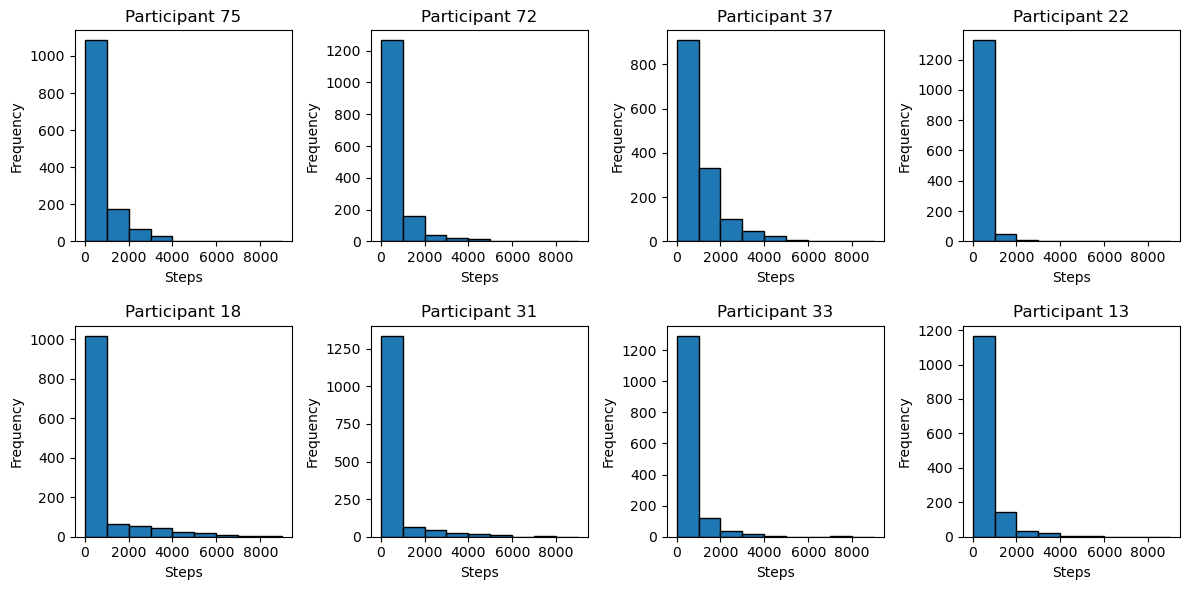

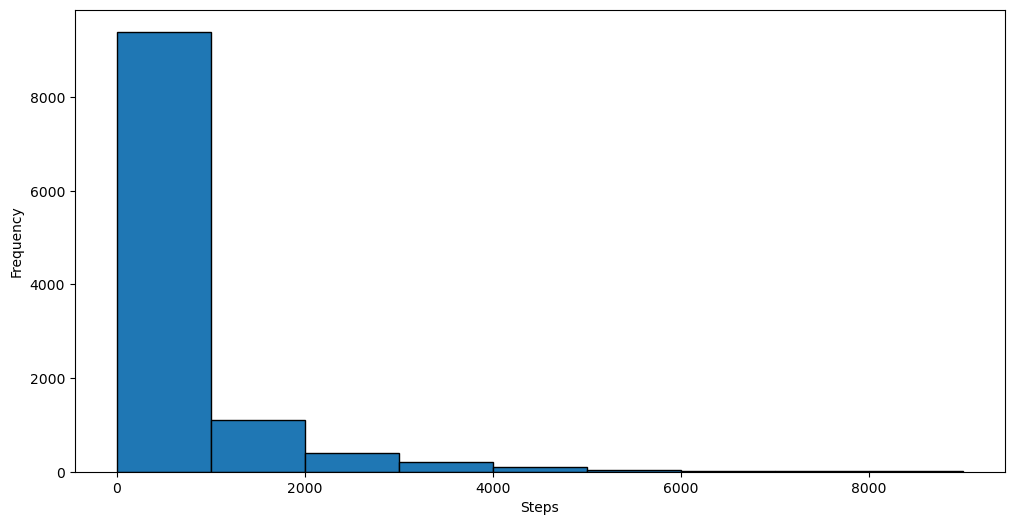

In [88]:
# plot hourly step count histogram for each participant separately
plt.figure(figsize=(12, 6))
for i, participant_id in enumerate(participant_ids):
    plt.subplot(2, 4, i + 1)
    plt.hist(hourly_stepcount_all[hourly_stepcount_all['participantidentifier'] == participant_id]['steps'], bins=range(0, 10000, 1000), edgecolor='black')
    plt.title(f'Participant {participant_id}')
    plt.xlabel('Steps')
    plt.ylabel('Frequency')
    plt.tight_layout(h_pad=1.5, w_pad=1.0)
plt.show()

# plot hourly step count histogram for all participants
plt.figure(figsize=(12, 6))
plt.hist(hourly_stepcount_all['steps'], bins=range(0, 10000, 1000), edgecolor='black')
plt.xlabel('Steps')
plt.ylabel('Frequency')
plt.show()


## Extract action delivery data (from analytics_event_push)
- walking suggestions
- salience messages
- end of day survey + planning prompt

In [89]:
# load analytics_event_push data
push_sent = pd.read_csv(os.path.join(folder, 'push_noti_sent.csv'))
push_sent.head()

,participantidentifier,timestamp,participantid,type,properties,_provenance
0,13,2025-05-23 15:18:52.000,f164d492-8e8f-4996-9310-6cc254a42d76,PushNotificationSent,"{Title=Welcome to HeartSteps!, Body=We greatly...","{exportstartdate=2025-05-23T00:00:00-07:00, s3..."
1,13,2025-06-15 22:00:22.000,f164d492-8e8f-4996-9310-6cc254a42d76,PushNotificationSent,"{Title=Message from Steppy, Body=Thank you for...","{exportstartdate=2025-06-15T00:00:00-07:00, s3..."
2,13,2025-06-16 02:00:15.000,f164d492-8e8f-4996-9310-6cc254a42d76,PushNotificationSent,"{Title=Message from Steppy, Body=Before you ca...","{exportstartdate=2025-06-15T00:00:00-07:00, s3..."
3,13,2025-06-16 12:30:29.000,f164d492-8e8f-4996-9310-6cc254a42d76,PushNotificationSent,"{Title=Message from Steppy, Body=Here’s a tiny...","{exportstartdate=2025-06-16T00:00:00-07:00, s3..."
4,13,2025-06-16 15:45:10.000,f164d492-8e8f-4996-9310-6cc254a42d76,PushNotificationSent,"{Title=Message from Steppy, Body=Think about y...","{exportstartdate=2025-06-16T00:00:00-07:00, s3..."


In [90]:
import re

push_sent['notification_id'] = (
    push_sent['properties']
    .str.extract(r'NotificationIdentifier=([^,}]+)', expand=False)
)

gif_rows      = push_sent.loc[push_sent['notification_id'].str.startswith('gif', na=False)].copy()
end_rows      = push_sent.loc[push_sent['notification_id'].str.startswith('endOfDay', na=False)].copy()
salience_rows = push_sent.loc[push_sent['notification_id'].str.startswith('salience', na=False)].copy()

print(gif_rows.head())
print(end_rows.head())
print(salience_rows.head())


    participantidentifier                timestamp  \
3                      13  2025-06-16 12:30:29.000   
7                      13  2025-06-18 12:30:10.000   
9                      13  2025-06-18 17:30:12.000   
11                     13  2025-06-19 12:30:11.000   
13                     13  2025-06-19 17:30:12.000   

                           participantid                  type  \
3   f164d492-8e8f-4996-9310-6cc254a42d76  PushNotificationSent   
7   f164d492-8e8f-4996-9310-6cc254a42d76  PushNotificationSent   
9   f164d492-8e8f-4996-9310-6cc254a42d76  PushNotificationSent   
11  f164d492-8e8f-4996-9310-6cc254a42d76  PushNotificationSent   
13  f164d492-8e8f-4996-9310-6cc254a42d76  PushNotificationSent   

                                           properties  \
3   {Title=Message from Steppy, Body=Here’s a tiny...   
7   {Title=Message from Steppy, Body=Pssst… I’ve g...   
9   {Title=Message from Steppy, Body=A smile is wa...   
11  {Title=Message from Steppy, Body=Good vibes in

In [91]:
# check the date range of the end of day survey for each participant
min_date_list = []
max_date_list = []
date_range_length_list = []
for participant_id in participant_ids:
    end_rows_participant = end_rows.loc[end_rows['participantidentifier'] == participant_id].copy()
    end_rows_participant['timestamp'] = pd.to_datetime(end_rows_participant['timestamp'])

    min_date = end_rows_participant['timestamp'].min()
    max_date = end_rows_participant['timestamp'].max()

    print(f"Participant {participant_id} end of day survey date range: {min_date} to {max_date}")
    min_date_list.append(min_date)
    max_date_list.append(max_date)

    # get the length of the date range
    date_range_length = (max_date - min_date).days + 1
    date_range_length_list.append(date_range_length)

print(min_date_list)
print(max_date_list)
print(date_range_length_list)




Participant 75 end of day survey date range: 2025-07-27 23:00:09 to 2025-10-19 23:00:52
Participant 72 end of day survey date range: 2025-07-27 22:30:25 to 2025-10-19 22:30:53
Participant 37 end of day survey date range: 2025-07-14 00:00:14 to 2025-10-05 22:00:40
Participant 22 end of day survey date range: 2025-06-30 13:00:07 to 2025-09-21 23:01:35
Participant 18 end of day survey date range: 2025-06-30 01:15:13 to 2025-09-21 21:15:34
Participant 31 end of day survey date range: 2025-07-07 00:00:28 to 2025-09-28 22:01:48
Participant 33 end of day survey date range: 2025-06-30 01:00:13 to 2025-09-21 23:02:08
Participant 13 end of day survey date range: 2025-06-16 02:00:15 to 2025-09-10 23:01:50
[Timestamp('2025-07-27 23:00:09'), Timestamp('2025-07-27 22:30:25'), Timestamp('2025-07-14 00:00:14'), Timestamp('2025-06-30 13:00:07'), Timestamp('2025-06-30 01:15:13'), Timestamp('2025-07-07 00:00:28'), Timestamp('2025-06-30 01:00:13'), Timestamp('2025-06-16 02:00:15')]
[Timestamp('2025-10-19 

In [92]:
# add 0/1 to indicate without planning prompt or with planning prompt in the end of day survey
end_rows['planning_prompt'] = 0
end_rows.loc[end_rows['notification_id'].str.startswith('endOfDay_Planning', na=False), 'planning_prompt'] = 1
# print(end_rows.head())

end_rows['timestamp'] = pd.to_datetime(end_rows['timestamp'])
end_rows['date'] = end_rows['timestamp'].dt.date
end_rows['time'] = end_rows['timestamp'].dt.time
df_end_all = end_rows[['participantidentifier', 'date', 'time', 'planning_prompt']]

print(df_end_all.head())


    participantidentifier        date      time  planning_prompt
2                      13  2025-06-16  02:00:15                0
5                      13  2025-06-17  01:00:15                0
6                      13  2025-06-18  01:00:31                1
10                     13  2025-06-19  01:00:24                1
14                     13  2025-06-20  01:00:24                0


In [93]:
# the above rows do not contain no delivery data, so we need to complete the data
# first, complete walking suggestions

# check the date range of the walking suggestions for each participant
df_gif_all = []  # Use list for efficient appending

for n in range(len(participant_ids)):
    participant_id = participant_ids[n]
    gif_rows_participant = gif_rows.loc[gif_rows['participantidentifier'] == participant_id].copy()
    gif_rows_participant['timestamp'] = pd.to_datetime(gif_rows_participant['timestamp'])    
    # extract the date and time from the timestamp
    gif_rows_participant['date'] = gif_rows_participant['timestamp'].dt.date
    gif_rows_participant['time'] = gif_rows_participant['timestamp'].dt.time

    min_date = min_date_list[n].date()
    max_date = max_date_list[n].date()
    date_range_length = date_range_length_list[n]

    # read wakeup and bedtime data for the participant
    df_wakeup_bedtime_participant = df_wakeup_bedtime.loc[df_wakeup_bedtime['participantidentifier'] == participant_id].copy()


    for i in range(date_range_length * 2):
        date = min_date + pd.Timedelta(days=i)
        if df_wakeup_bedtime_participant.shape[0] == 1:
            weekday_wakeup = df_wakeup_bedtime_participant['weekday_wakeup'].iloc[0]
            weekend_wakeup = df_wakeup_bedtime_participant['weekend_wakeup'].iloc[0]
        else:
            change_date = df_wakeup_bedtime_participant['date']
            weekday_wakeup = df_wakeup_bedtime_participant['weekday_wakeup'].iloc[0]
            weekend_wakeup = df_wakeup_bedtime_participant['weekend_wakeup'].iloc[0]
            
            for j in range(len(df_wakeup_bedtime_participant)):
                change_date = df_wakeup_bedtime_participant['date'].iloc[j]
                
                # Check if this is the applicable period
                if j < len(df_wakeup_bedtime_participant) - 1:
                    next_change_date = df_wakeup_bedtime_participant['date'].iloc[j + 1]
                    if change_date <= date < next_change_date:
                        weekday_wakeup = df_wakeup_bedtime_participant['weekday_wakeup'].iloc[j]
                        weekend_wakeup = df_wakeup_bedtime_participant['weekend_wakeup'].iloc[j]
                        break
                else:
                    # Last entry - applies from change_date onwards
                    if change_date <= date:
                        weekday_wakeup = df_wakeup_bedtime_participant['weekday_wakeup'].iloc[j]
                        weekend_wakeup = df_wakeup_bedtime_participant['weekend_wakeup'].iloc[j]
                        break
        
        # Determine wakeup time based on weekday/weekend
        is_weekday = date.weekday() < 5
        wakeup_time = weekday_wakeup if is_weekday else weekend_wakeup

        wake_td = pd.Timedelta(hours=wakeup_time.hour, minutes=wakeup_time.minute, seconds=wakeup_time.second)
        m_time = wake_td + pd.Timedelta(minutes=60)   # Morning: 1 hour after wake
        a_time = wake_td + pd.Timedelta(minutes=360)  # Afternoon: 6 hours after wake

        # search for date and time in gif_rows_participant
        gif_row = gif_rows_participant.loc[(gif_rows_participant['date'] == date)]

        if gif_row.shape[0] == 2:
            for time_val in gif_row['time'].values:
                df_gif_all.append({
                    'participantidentifier': participant_id,
                    'date': date,
                    'time': time_val,
                    'walking_suggestion': 1
                })
        elif gif_row.shape[0] == 1:
            # One delivery - determine if it's morning or afternoon
            delivered_time = gif_row['time'].iloc[0]
            
            # Convert time to timedelta for comparison
            delivered_td = pd.Timedelta(
                hours=delivered_time.hour, 
                minutes=delivered_time.minute, 
                seconds=delivered_time.second
            )
            
            # Check which slot it's closer to
            is_morning = abs((delivered_td - m_time).total_seconds()) < abs((delivered_td - a_time).total_seconds())
            
            if is_morning:
                # Delivered in morning, not in afternoon
                df_gif_all.append({
                    'participantidentifier': participant_id,
                    'date': date,
                    'time': delivered_time,
                    'walking_suggestion': 1
                })
                df_gif_all.append({
                    'participantidentifier': participant_id,
                    'date': date,
                    'time': (pd.Timestamp('2000-01-01') + a_time).time(),
                    'walking_suggestion': 0
                })
            else:
                # Delivered in afternoon, not in morning
                df_gif_all.append({
                    'participantidentifier': participant_id,
                    'date': date,
                    'time': (pd.Timestamp('2000-01-01') + m_time).time(),
                    'walking_suggestion': 0
                })
                df_gif_all.append({
                    'participantidentifier': participant_id,
                    'date': date,
                    'time': delivered_time,
                    'walking_suggestion': 1
                })
        else:
            # No deliveries - both slots empty
            df_gif_all.append({
                'participantidentifier': participant_id,
                'date': date,
                'time': (pd.Timestamp('2000-01-01') + m_time).time(),
                'walking_suggestion': 0
            })
            df_gif_all.append({
                'participantidentifier': participant_id,
                'date': date,
                'time': (pd.Timestamp('2000-01-01') + a_time).time(),
                'walking_suggestion': 0
            })

df_gif_all = pd.DataFrame(df_gif_all)
print(df_gif_all.head(20))

# print(gif_rows[gif_rows['participantidentifier'] == 75].head(20))

    participantidentifier        date      time  walking_suggestion
0                      75  2025-07-27  09:00:00                   0
1                      75  2025-07-27  14:00:00                   0
2                      75  2025-07-28  09:00:00                   0
3                      75  2025-07-28  13:00:12                   1
4                      75  2025-07-29  09:00:00                   0
5                      75  2025-07-29  13:00:10                   1
6                      75  2025-07-30  09:00:00                   0
7                      75  2025-07-30  14:00:00                   0
8                      75  2025-07-31  09:00:00                   0
9                      75  2025-07-31  13:00:15                   1
10                     75  2025-08-01  09:00:00                   0
11                     75  2025-08-01  13:00:10                   1
12                     75  2025-08-02  13:00:11                   1
13                     75  2025-08-02  18:00:21 

In [94]:
# second, complete salience messages

df_salience_all = []
# check the date range of the salience messages
for n in range(len(participant_ids)):
    participant_id = participant_ids[n]
    salience_rows_participant = salience_rows.loc[salience_rows['participantidentifier'] == participant_id].copy()
    salience_rows_participant['timestamp'] = pd.to_datetime(salience_rows_participant['timestamp'])
    # print(f"Participant {participant_id} salience messages date range: {salience_rows_participant['timestamp'].min()} to {salience_rows_participant['timestamp'].max()}")

    # extract the date and time from the timestamp
    salience_rows_participant['date'] = salience_rows_participant['timestamp'].dt.date
    salience_rows_participant['time'] = salience_rows_participant['timestamp'].dt.time

    min_date = min_date_list[n].date()
    max_date = max_date_list[n].date()
    date_range_length = date_range_length_list[n]

    for i in range(date_range_length):
        date = min_date + pd.Timedelta(days=i)
        salience_row = salience_rows_participant.loc[(salience_rows_participant['date'] == date)]
        if salience_row.shape[0] == 1:
            df_salience_all.append({
                'participantidentifier': participant_id,
                'date': date,
                'time': salience_row['time'].iloc[0],
                'salience_message': 1
            })
        else:
            df_salience_all.append({
                'participantidentifier': participant_id,
                'date': date,
                'time': (pd.Timestamp('2000-01-01') + pd.Timedelta(hours=11, minutes=45)).time(),
                'salience_message': 0
            })

df_salience_all = pd.DataFrame(df_salience_all)
print(df_salience_all.head(10))


   participantidentifier        date      time  salience_message
0                     75  2025-07-27  11:45:00                 0
1                     75  2025-07-28  11:45:00                 0
2                     75  2025-07-29  15:45:09                 1
3                     75  2025-07-30  15:45:08                 1
4                     75  2025-07-31  11:45:00                 0
5                     75  2025-08-01  11:45:00                 0
6                     75  2025-08-02  11:45:00                 0
7                     75  2025-08-03  15:45:07                 1
8                     75  2025-08-04  15:45:06                 1
9                     75  2025-08-05  11:45:00                 0


## Extract page views


In [95]:
pageview = pd.read_csv(os.path.join(folder, 'analytics_views.csv'))
print(pageview.head())

   participantidentifier                timestamp  \
0                     13  2025-05-23 15:06:10.000   
1                     13  2025-05-23 15:06:11.000   
2                     13  2025-05-23 15:06:11.000   
3                     13  2025-05-23 15:06:12.000   
4                     13  2025-05-23 15:06:32.000   

                          participantid                   type  \
0  f164d492-8e8f-4996-9310-6cc254a42d76     ParticipantUpdated   
1  f164d492-8e8f-4996-9310-6cc254a42d76       NotificationSent   
2  f164d492-8e8f-4996-9310-6cc254a42d76  EmailNotificationSent   
3  f164d492-8e8f-4996-9310-6cc254a42d76              EmailSend   
4  f164d492-8e8f-4996-9310-6cc254a42d76          EmailDelivery   

                                          properties  \
0  {User=steverac, Change={"Demographics":{"Email...   
1  {RecipientOverride=None, Recipients=["patelmes...   
2  {To=patelmesser@gmail.com, Subject=ADAPT invit...   
3  {MailDestination=patelmesser@gmail.com, MailTi...   
4  {

In [96]:
# filter type - ViewViewed
pageview = pageview.loc[pageview['type'] == 'ViewViewed'].copy()
pageview['timestamp'] = pd.to_datetime(pageview['timestamp'])
pageview['date'] = pageview['timestamp'].dt.date
pageview['time'] = pageview['timestamp'].dt.time
# print(pageview.head())

df_pageview_all = []
for n in range(len(participant_ids)):
    participant_id = participant_ids[n]
    pageview_participant = pageview.loc[pageview['participantidentifier'] == participant_id].copy()
    min_date = min_date_list[n].date()
    max_date = max_date_list[n].date()
    # print(date_range)
    # Use between() to filter dates in range
    pageview_participant = pageview_participant.loc[
        (pageview_participant['date'] >= min_date) & 
        (pageview_participant['date'] <= max_date)
    ].copy()    
    
    df_pageview_all.append(pageview_participant)

df_pageview_all = pd.concat(df_pageview_all, ignore_index=True)
df_pageview_all = df_pageview_all[['participantidentifier', 'date', 'time']]
print(df_pageview_all.head(10))


### TODO: match the number of pageviews with the walking suggestions

   participantidentifier        date      time
0                     75  2025-08-04  14:02:28
1                     75  2025-08-04  14:03:55
2                     75  2025-08-04  14:06:46
3                     75  2025-08-04  16:32:54
4                     75  2025-08-04  16:32:56
5                     75  2025-08-15  16:55:42
6                     75  2025-08-15  16:59:01
7                     75  2025-08-15  16:59:05
8                     75  2025-08-15  16:59:14
9                     75  2025-08-15  16:59:29


## Extract physical activity logs data from fitbit

In [97]:
log_data = pd.read_csv(os.path.join(folder, 'fitbitactivitylogs.csv'))
# print(log_data.head())
log_data['startdate'] = pd.to_datetime(log_data['startdate'])
log_data['date'] = log_data['startdate'].dt.date
log_data['time'] = log_data['startdate'].dt.time

print(log_data['activityname'].unique())


df_log_all = []
for n in range(len(participant_ids)):
    participant_id = participant_ids[n]
    log_data_participant = log_data.loc[log_data['participantidentifier'] == participant_id].copy()
    
    min_date = min_date_list[n].date()
    max_date = max_date_list[n].date()

    log_data_participant = log_data_participant.loc[
        (log_data_participant['date'] >= min_date) & 
        (log_data_participant['date'] <= max_date)
    ].copy()

    df_log_all.append(log_data_participant)
    

df_log_all = pd.concat(df_log_all, ignore_index=True)
print(df_log_all.head(10))




['Elliptical' 'Walk' 'Spinning' 'Swim' 'Strength training' 'Run' 'Sport'
 'Outdoor Bike']
   participantidentifier           startdate                  enddate  \
0                     75 2025-07-28 18:35:24  2025-07-28 18:58:01.000   
1                     75 2025-07-29 14:01:05  2025-07-29 14:23:33.000   
2                     75 2025-08-01 09:35:09  2025-08-01 21:04:00.000   
3                     75 2025-08-01 21:28:37  2025-08-01 21:50:48.000   
4                     75 2025-08-02 05:47:30  2025-08-02 06:32:05.000   
5                     75 2025-08-02 13:11:38  2025-08-02 13:39:48.000   
6                     75 2025-08-02 15:05:59  2025-08-02 15:43:22.000   
7                     75 2025-08-02 15:55:34  2025-08-02 16:28:58.000   
8                     75 2025-08-05 16:38:37  2025-08-05 17:08:25.000   
9                     75 2025-08-07 18:15:27  2025-08-07 18:43:03.000   

   activeduration activityname  activitytypeid  averageheartrate  calories  \
0         1357000         Wa